## 第二次讀書會專案：針對PTT軍事版以及八卦版中對於美國出兵伊朗相關文章- 文辭與文件分析、文件分類與主題模型分析
### 組別：Group_3
#### 組員：
* M144020008 洪宏林
* M144020017 陳姿佑
* M144020019 顏志豪
* M144020058 黄鈞浩
* M144020002 吳俊廷
* M144020028 白茗仁
* M144020061 黃博章
* B124020008 李怡君
##### 詳細檔案可到：https://github.com/Sylvan945/Social_Network_Analysis_Group_3

#### 專案動機：
1.	國際危機下的社會： 2026年3月初，伊朗局勢成為國際焦點，短短 20 天內在 PTT 雙看板（八卦版、戰爭版）湧現逾兩千篇文章。面對遠在天邊的中東衝突，台灣網友的反應並非漠不關心，而是投射了強烈的情緒。透過情緒分析，我們能捕捉到這些隱藏在文字背後的社會集體心理狀態。

2.	數位社群的輿論場域與資訊噪音： 路討論中充斥著即時戰報、外交口水、經濟焦慮，甚至伴隨著各種立場的訊息來源（如大紀元、中央社、外電翻譯）。在動輒數千篇的文章中，分析輿論的演變軌跡與核心議題。

3.	台灣視角的在地化解讀： 解析社群在面對全球危機時的關注差異，並透過分析揭示輿論焦點是什麼。

#### 1.資料介紹
##### 資料來源：
* Python爬蟲收集PTT平台上與《伊朗》相關的文章
* 來源：戰爭版/八卦版
* 關鍵字：伊朗
* 時間： 2026/03/01~2026/04/10
* 資料筆數：共 3547篇文章


# 一、文辭與文件分析

#### 1.1 初始設定

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import re
import jieba
import jieba.analyse
import math
from nltk import ngrams, FreqDist
from collections import Counter, namedtuple

import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
#if not os.path.exists('font.ttf'):
#    !wget -O font.ttf https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf

font_path = './font.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'Noto Sans TC'
# 確保圖表中的負號 (-) 能正常顯示
plt.rcParams['axes.unicode_minus'] = False
print("字體設定完成！")

字體設定完成！


In [3]:
#or system font
system_font = r"C:/Windows/Fonts/msjh.ttc"
prop = fm.FontProperties(fname=system_font)
plt.rcParams['font.sans-serif']=['Microsoft JhengHei']

#### 1.2 讀取與基本清洗

In [4]:
# 讀取檔案
df = pd.read_csv('../data/ptt_iran_20260301_0410_full.csv')
clear_df = df.copy() # 複製一份資料進行清洗，保留原始資料以供對照

# 定義並去除分析時用不到的系統與詮釋資料欄位
drop_cols = ['system_id', 'artCatagory', 'artUrl', 'artPoster', 'insertedDate','artComment','dataSource']
clear_df.drop(drop_cols, axis=1, inplace=True, errors='ignore')

# 移除內文 (artContent) 為空值的資料行
clear_df.dropna(subset=['artContent'], inplace=True)

clear_df.head()

,artTitle,artDate,artContent
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...
1,[情報] 幾則關於伊朗戰爭的民調,2026-04-10 16:20:52,https://x.com/NateSilver538/status/20398397434...
2,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,2026-04-10 15:54:15,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry...
3,[情報] 報導稱以色列軍方認為伊朗政府更為極端,2026-04-10 15:42:14,https://x.com/Osinttechnical/status/2042422868...
4,[新聞] 曾嗆發展核武，伊朗前外長傷重不治,2026-04-10 14:09:37,曾揚言發展核武！伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難\r\n\r\n\r\n\r\n伊...


#### 1.3 PTT 專屬進階文字清理

In [5]:

def clean_ptt_text(text):
    """清理 PTT 文章中常見的雜訊 (網址、簽名檔、引言等)"""
    text = str(text)
    
    # 1. 移除網址 (你原本的寫法很好)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 2. 移除 PTT 常見結尾資訊 (發信站、文章網址、編輯記錄)
    # 只要是 "※" 開頭且後面跟著這三個關鍵字，整行連同後面的內容都砍掉
    text = re.sub(r'※ (發信站|文章網址|編輯).*', '', text)
    
    # 3. 移除回文引述
    text = re.sub(r'引述《.*》之銘言', '', text)
    
    # 4. 移除標題標籤，例如 [新聞]、[爆卦]
    text = re.sub(r'\[.*?\]', '', text)
    
    # 5. 移除回文時常見的引言符號 (PTT 每行引言常以 : 或 > 開頭)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)
    
    # 6. 移除純英文和數字 (依你原本的邏輯保留)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    
    # 7. 清除常見的無意義連續符號，例如 --, //, ==, ~~
    text = re.sub(r'[-/=_~]{2,}', '', text)
    
    # 8. 換行轉句號
    text = re.sub(r'\n+', '。', text)
    
    return text

# 將清理函式套用到內文欄位
clear_df['sentence'] = clear_df['artContent'].apply(clean_ptt_text)

# 在斷句前，先將目前的 index 存成 'doc' 欄位，這樣斷句後編號才會留著
clear_df['doc'] = clear_df.index
# 斷句：利用標點符號將整篇文章切分成一句一句的短句
clear_df['sentence'] = clear_df['sentence'].str.split(r"[,，。！!？?]+")
# explode 會將串列中的句子拆解成多列，重置索引
sent_df = clear_df.explode('sentence').reset_index(drop=True)
# 濾除只有 1 個字或全空的無效短句
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

print("\n=== 文字清理與斷句完成 ===")
print(f"目前總共切出了 {len(sent_df)} 句短句準備進行斷詞！")

sent_df


=== 文字清理與斷句完成 ===
目前總共切出了 137637 句短句準備進行斷詞！


,artTitle,artDate,artContent,sentence,doc
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞出處：\r,0
3,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞內容摘要：\r,0
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0
5,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,萬眾矚目的談判,0
6,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,外媒披露,0
...,...,...,...,...,...
214593,[問卦] 愛潑斯坦被戳的小孩跟被炸死的伊朗哪個慘,2026-03-01 00:06:26,如題，\r\n\r\n有人說艾波斯坦給小孩錢，\r\n還有花錢請人生嬰兒來吃，\r\n很邪惡...,卻不承認自己沒資格,3545
214598,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026-03-01 00:01:58,https://i.imgur.com/FrMBP3e.jpeg\r\n\r\n以色列電視台...,以色列電視台頻道快訊說\r,3546
214599,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026-03-01 00:01:58,https://i.imgur.com/FrMBP3e.jpeg\r\n\r\n以色列電視台...,伊朗精神導師哈米尼已身亡\r,3546
214601,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026-03-01 00:01:58,https://i.imgur.com/FrMBP3e.jpeg\r\n\r\n以色列電視台...,所以戰爭要結束了嗎,3546


#### 1.4. 文章斷詞與整理

In [6]:
# 設定繁體中文字典
jieba.set_dictionary('../dict/dict.txt')

# 加入專案關鍵字，避免斷詞時被切碎
custom_words = ['防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東', '大馬士革', '德黑蘭','哈梅內伊','霍爾木茲海峽','荷姆茲海峽','荷莫茲海峽']
for w in custom_words:
    jieba.add_word(w)

# 讀取停用字清單
with open('../dict/stopwords.txt', encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 定義斷詞邏輯：過濾停用字與長度小於 2 的詞
def getToken(row):
    seg_list = jieba.lcut(row)
    return [w for w in seg_list if w not in stopWords and len(w.strip()) > 1]

# 執行斷詞並將結果展開成長表格 (word_df)
word_df = sent_df.assign(word = sent_df['sentence'].apply(getToken)).explode('word')
word_df = word_df.dropna(subset=['word'])

# 檢查產出的總詞數與前幾筆資料
print(f"目前總詞數：{len(word_df)}")
word_df.head()

Building prefix dict from C:\Users\justi\OneDrive\文件\中山碩士\社媒\Social_Network_Analysis_Group_3-main\groupwork2\dict\dict.txt ...
Loading model from cache C:\Users\justi\AppData\Local\Temp\jieba.u8028ad36b404e2a685691e04a294fe4e.cache
Loading model cost 0.373 seconds.
Prefix dict has been built successfully.


目前總詞數：491727


,artTitle,artDate,artContent,sentence,doc,word
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞出處：\r,0,新聞
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞出處：\r,0,出處
3,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞內容摘要：\r,0,新聞
3,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞內容摘要：\r,0,內容
3,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞內容摘要：\r,0,摘要


#### 1.5. 最終停用字過濾

In [7]:
# 讀取停用字檔
try:
    with open('/content/stopwords.txt', 'r', encoding='utf-8') as f:
        stopwords = set([line.strip() for line in f])
except FileNotFoundError:
    stopwords = set()

if 'stopWords' not in locals():
    stopWords = list(stopwords)

# 更新手動停用字名單
stopwords_manual = {"-----", "----", "連結", "嘖嘖", "醒醒", "裝睡", "衛生紙", "乳摸", "高潮", "新聞", "內文", "備註", "刪除", "完整", "轉載", "編輯", "張貼", "署名", "文章", "標題", "報導", "八卦", "看板", "作者", "時間", "來源", "內容", "媒體", "情況", "問題", "如題", "原因", "網址", "發信", "實業", "cc", "ptt", "gossiping", "www", "com", "https", "http", "share", "url", "index", "html", "bbs", "status","表示", "行動", "國家", "當作", "出現", "晚間", "政府","目前","請放", "最後", "違者", "未滿", "繁體", "中文字", "水桶", "一天", "以天", "單位",'網友', '點擊'}
stopWords.extend(list(stopwords_manual))

stopWords = list(set(stopWords))

# 執行過濾 (將過濾後的結果存回 word_df)
word_df = word_df[~word_df['word'].isin(stopWords)]


In [8]:
print("=== 🧹 去除停用字後的 TOP 20 關鍵字 ===")
clean_top_words = word_df['word'].value_counts().head(20)
print(clean_top_words)

# 觀察方法 B：隨機抽樣看幾筆資料的長相
print("\n=== 🎲 word_df 隨機抽樣 5 筆 ===")
# 使用 sample() 而不是 head()，可以更客觀地看到分散在各處的詞彙
print(word_df[['doc', 'word']].sample(5))

=== 🧹 去除停用字後的 TOP 20 關鍵字 ===
word
伊朗     20745
美國     10189
川普      5460
以色列     4178
戰爭      3457
攻擊      2636
美軍      2560
中國      2227
飛彈      2216
軍事      1831
現在      1810
總統      1681
目標      1567
中東      1554
無人機     1534
打擊      1455
官員      1390
台灣      1211
談判      1208
政權      1189
Name: count, dtype: int64

=== 🎲 word_df 隨機抽樣 5 筆 ===
         doc word
68551    743   綜合
27376    262  濃縮鈾
67102    716   第五
146995  2230   本來
42859    421   搭建


#### 1.6. 同義詞替換

In [9]:
synonyms = {
    '哈梅內伊': '哈米尼',
    'Donald Trump': '川普',
    '阿川': '川普',
    '川皇': '川普',
    '荷莫茲':'荷姆茲',
    '霍爾木茲': '荷姆茲'
}
word_df['word'] = word_df['word'].replace(synonyms)

#### 2.1 計算TF-IDF

##### 計算各文章詞彙數與 TF 值

In [10]:
# 1. 計算每篇文章的總詞數
total_words = word_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})

# 2. 重新計算各文章內，每個詞彙出現的次數
word_count = word_df.groupby(['doc', 'word'], as_index=False).size()
word_count.rename(columns={'size': 'count'}, inplace=True)

# 3. 合併總詞數產生 sample_merged
sample_merged = word_count.merge(total_words, on='doc', how='left')

# 4. 計算 TF 值
sample_tf_idf = sample_merged.assign(tf = sample_merged["count"] / sample_merged["total"])

# 5. 檢查結果
sample_tf_idf.head()

,doc,word,count,total,tf
0,0,一道,1,136,0.007353
1,0,上空,1,136,0.007353
2,0,中央社,1,136,0.007353
3,0,主場,1,136,0.007353
4,0,今日,1,136,0.007353


In [11]:
# 依照文章編號 (doc) 分組，計算每篇文章總共切出了多少個詞
total_words = word_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})

total_words.head()

# 計算每個詞彙出現在多少篇文章中 (Document Frequency)
idf_df = sample_merged.groupby(['word'], as_index=False).size()

# 將出現篇數合併回主表
sample_tf_idf = sample_tf_idf.merge(idf_df, on='word', how='left')

# 計算 IDF = log10( 總文章數 / 包含該詞的文章數 )
# 使用 math.log(x, 10) 代表以 10 為底的對數
N = len(total_words)
sample_tf_idf = sample_tf_idf.assign(
    idf = sample_tf_idf["size"].apply(lambda size: math.log(N / size, 10))
).drop(["size"], axis=1)

# 檢查合併 IDF 後的結果
sample_tf_idf.head()

,doc,word,count,total,tf,idf
0,0,一道,1,136,0.007353,2.508346
1,0,上空,1,136,0.007353,1.717230
2,0,中央社,1,136,0.007353,1.641254
3,0,主場,1,136,0.007353,2.850769
4,0,今日,1,136,0.007353,1.868497


##### 計算 IDF 值

In [12]:
# 計算每個詞彙出現在多少篇文章中 (Document Frequency)
idf_df = sample_merged.groupby(['word'], as_index=False).size()

# 將出現篇數合併回主表
sample_tf_idf = sample_tf_idf.merge(idf_df, on='word', how='left')

# 計算 IDF = log10( 總文章數 / 包含該詞的文章數 )
# 使用 math.log(x, 10) 代表以 10 為底的對數
N = len(total_words)
sample_tf_idf = sample_tf_idf.assign(
    idf = sample_tf_idf["size"].apply(lambda size: math.log(N / size, 10))
).drop(["size"], axis=1)

# 檢查合併 IDF 後的結果
sample_tf_idf.head()

,doc,word,count,total,tf,idf
0,0,一道,1,136,0.007353,2.508346
1,0,上空,1,136,0.007353,1.717230
2,0,中央社,1,136,0.007353,1.641254
3,0,主場,1,136,0.007353,2.850769
4,0,今日,1,136,0.007353,1.868497


##### 計算 TF-IDF 並選出文章關鍵詞

In [13]:
# 計算 TF-IDF = TF * IDF
sample_tf_idf = sample_tf_idf.assign(tf_idf = sample_tf_idf["tf"] * sample_tf_idf["idf"])

# 依照 TF-IDF 分數排序，查看全資料集權重最高的詞
print("--- 全資料集權重前 10 名 ---")
display(sample_tf_idf.sort_values('tf_idf', ascending=False).head(10))

# 提取每篇文章 TF-IDF 值最高的前三個詞 (作為文章標籤)
print("\n--- 每篇文章的關鍵詞 (Top 3) ---")
group_keywords = sample_tf_idf.groupby("doc").apply(lambda x: x.nlargest(3, "tf_idf"), include_groups=False)
group_keywords.head(15)

--- 全資料集權重前 10 名 ---


,doc,word,count,total,tf,idf,tf_idf
26042,161,該機,1,2,0.500000,2.947679,1.473839
26041,161,彈射,1,2,0.500000,2.345619,1.172809
192181,1923,喔喔,10,28,0.357143,3.248709,1.160253
311393,3528,飯店,2,6,0.333333,2.087341,0.695780
76712,520,第天,2,6,0.333333,1.993436,0.664479
311510,3535,火柴,1,5,0.200000,3.248709,0.649742
180560,1749,天使,9,43,0.209302,2.947679,0.616956
20927,132,戰敗,3,11,0.272727,2.227519,0.607505
222137,2316,機械,4,19,0.210526,2.850769,0.600162
76710,520,插圖,1,6,0.166667,3.549739,0.591623



--- 每篇文章的關鍵詞 (Top 3) ---


word  count  total        tf       idf    tf_idf
doc                                                      
0   34   巴基斯坦      9    136  0.066176  1.403611  0.092886
    35     巴德      3    136  0.022059  2.188011  0.048265
    63     空域      3    136  0.022059  2.031225  0.044806
1   125    民調      4     66  0.060606  1.886981  0.114362
    124    民眾      6     66  0.090909  1.233768  0.112161
    118   支持度      3     66  0.045455  2.248709  0.102214
2   314    晶片      7    525  0.013333  2.345619  0.031275
    213    台灣     17    525  0.032381  0.814939  0.026388
    243    封鎖     12    525  0.022857  1.027294  0.023481
3   483    另稱      1     31  0.032258  2.850769  0.091960
    502    軍方      2     31  0.064516  1.164132  0.075105
    500    著手      1     31  0.032258  2.319290  0.074816
4   534    哈拉      4    149  0.026846  3.549739  0.095295
    600    老人      2    149  0.013423  2.345619  0.031485
    559   德黑蘭      5    149  0.033557  0.896526  0.030085

#### 2.2 建立 DTM 格式資料集

In [14]:
# 1. 複製一份資料進行 DTM 分析
ptt_dtm_df = df.copy()

# 2. 保留需要的欄位，並填補空值
ptt_dtm_df['artContent'] = ptt_dtm_df['artContent'].fillna('')

# 3. 確保只取需要的欄位
ptt_dtm_df = ptt_dtm_df.loc[:, ["artTitle", "artContent"]]

ptt_dtm_df['cleaned_content'] = ptt_dtm_df['artContent'].apply(clean_ptt_text)

# 4. 執行斷詞並用空格串接
ptt_dtm_df['word'] = ptt_dtm_df['cleaned_content'].apply(getToken).map(' '.join)

# 檢查結果
ptt_dtm_df.head()

,artTitle,artContent,cleaned_content,word
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞出處：\r。\r。\r。新聞內容摘要：\r。（中央社新德里日綜合外電報導）美國與伊朗將於...,出處 摘要 中央社 新德里 綜合 外電 美國 伊朗 將於日 巴基斯坦 首都 伊斯蘭 巴德 舉...
1,[情報] 幾則關於伊朗戰爭的民調,https://x.com/NateSilver538/status/20398397434...,\r。根據 的統整各間民調，\r。可見美國民眾對伊朗戰爭的支持度持續下滑\r。\r。\r。\...,統整 各間 民調 美國 民眾 伊朗 戰爭 支持度 持續 下滑 民調 追蹤 美國 民眾 以色列...
2,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry...,大西洋期刊，我對這篇文章不予置評，僅供參考\r。\r。\r。\r。中國從伊朗戰爭中學到了什麼...,大西洋 期刊 這篇 不予置評 參考 中國 伊朗 戰爭 中學 台灣 實施 封鎖 全球 經濟 造...
3,[情報] 報導稱以色列軍方認為伊朗政府更為極端,https://x.com/Osinttechnical/status/2042422868...,\r。\r。以色列媒體報導\r。\r。以色列軍方告訴國會議員說伊朗的新政府比戰前的更極端\r...,以色列 以色列 軍方 告訴 國會 議員 伊朗 戰前 以色列 軍方 另稱 作戰 伊朗 造成 嚴...
4,[新聞] 曾嗆發展核武，伊朗前外長傷重不治,曾揚言發展核武！伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難\r\n\r\n\r\n\r\n伊...,曾揚言發展核武！伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難\r。\r。\r。\r。伊朗媒體報...,揚言 發展 核武 伊朗 外長 拉齊 遇襲 住所 攻擊 罹難 伊朗 伊朗 外交部長 哈拉 美國...


In [15]:
# 1. 限制詞彙量：只取詞頻前 1000 高的詞
# 2. 移除太冷門的詞：至少要在 5 篇文章出現過
vectorizer = CountVectorizer(max_features=1000, min_df=5)

# 重新學習與轉換
X = vectorizer.fit_transform(ptt_dtm_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉換成 DataFrame
DTM_df = pd.DataFrame(columns=vocabulary, data=X.toarray())
DTM_df.head()

,一下,一份,一位,一名,一堆,一場,一枚,一架,一次,一段,...,飛行員,首次,首都,體制,體系,高層,高度,高級,鵝肝,黎巴嫩
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [16]:
# 1. 初始化轉換器
transformer = TfidfTransformer()

# 2. 將剛才算好的次數矩陣 X 轉換為權重
tfidf_matrix = transformer.fit_transform(X)

# 3. 建立 TFIDF_df
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf_matrix.toarray())

# 檢查
TFIDF_df.head()

,一下,一份,一位,一名,一堆,一場,一枚,一架,一次,一段,...,飛行員,首次,首都,體制,體系,高層,高度,高級,鵝肝,黎巴嫩
0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.084672,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.040521,0.0,0.0,0.0,0.033651,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.079873,0.0,0.0,0.0,0.0


#### 2.3 檢視結果

##### 方法 1：計算各詞彙在所有文章中的 TF-IDF 平均值

In [17]:
# 計算每個詞在所有文件裡的 TF-IDF 平均值
ptt_tfidf_avg = TFIDF_df.mean().to_frame().reset_index()
ptt_tfidf_avg.columns = ["word", "avg"]

# 排序並查看前 10 名
ptt_tfidf_avg.sort_values('avg', ascending=False).head(10)

,word,avg
84,伊朗,0.151257
735,美國,0.092505
332,川普,0.062014
78,以色列,0.045218
407,戰爭,0.037479
39,中國,0.037311
630,現在,0.036123
741,美軍,0.036114
196,台灣,0.033162
471,攻擊,0.030187


##### 方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [18]:
# 複製矩陣並插入文章編號
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index + 1)

# 將寬表格轉為長表格，方便進行分組運算
toptens_melted = toptens.melt(id_vars="doc_id", var_name="word", value_name='tfidf')

toptens_melted.head()

,doc_id,word,tfidf
0,1,一下,0.0
1,2,一下,0.0
2,3,一下,0.0
3,4,一下,0.0
4,5,一下,0.0


In [19]:
# 1. 確保只選取 TF-IDF 大於 0 的詞（避免抓到沒出現在該文中的詞）
# 並且排除掉純數字的詞 (例如 2026, 1300 等)
top_10_per_doc = (
    toptens_melted[toptens_melted['tfidf'] > 0]
    .groupby("doc_id")
    .apply(lambda x: x.nlargest(10, "tfidf"), include_groups=False)
    .reset_index(drop=True)
)

# 2. 進階過濾：排除純數字
top_10_per_doc = top_10_per_doc[~top_10_per_doc['word'].str.isnumeric()]

# 3. 重新計算每個詞被選入 Top 10 的總次數
top_word_frequency = (
    top_10_per_doc.groupby(['word'], as_index=False)
    .size()
    .sort_values('size', ascending=False)
)

# 4. 顯示結果
print("--- 熱門關鍵字 Top 10 ---")
top_word_frequency.head(10)

--- 熱門關鍵字 Top 10 ---


,word,size
83,伊朗,1847
733,美國,890
331,川普,599
77,以色列,358
739,美軍,312
38,中國,304
628,現在,281
406,戰爭,280
195,台灣,279
983,飛彈,251


#### 3.透過結巴斷詞與N-gram幫助建立斷詞字典

##### 3.1 建立 Bigram 斷詞函式

In [20]:
# 定義 ngram 斷詞函式
def ngram_getToken(row, n):
    # 1. 進行斷詞
    seg_list = jieba.lcut(row)

    # 2. 篩選停用字與長度小於 2 的詞
    seg_list = [w for w in seg_list if w not in stopWords and len(w.strip()) > 1]

    # 3. 產生 ngram 組合並用空格串接
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]

    return seg_list

In [21]:
# 複製一份資料進行 Bigram 分析
ptt_bigram = sent_df.copy()

# 執行 Bigram 斷詞並展開
ptt_bigram["word"] = ptt_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
ptt_bigram = ptt_bigram.explode('word').dropna(subset=['word'])

# 檢查前三筆組合
ptt_bigram.head(3)

,artTitle,artDate,artContent,sentence,doc,word
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,中央社 新德里
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,新德里 綜合
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,綜合 外電


In [22]:
# 計算每個組合出現的次數
ptt_bigram_count = ptt_bigram['word'].value_counts().reset_index()
ptt_bigram_count.columns = ['word', 'count']

# 顯示前 15 名常出現的組合
ptt_bigram_count.sort_values('count', ascending=False).head(15)

,word,count
0,美國 以色列,887
1,美國 總統,538
2,美國 伊朗,474
3,伊朗 戰爭,467
4,總統 川普,454
5,地面 部隊,376
6,這場 戰爭,345
7,消息 人士,323
8,伊斯蘭 革命衛隊,314
9,彈道 飛彈,312


##### 3.2 Trigram 斷詞與展開

In [23]:
# 複製資料進行 Trigram 分析
ptt_trigram = sent_df.copy()

# 執行 Trigram 斷詞 (n=3) 並展開
ptt_trigram["word"] = ptt_trigram['sentence'].apply(lambda row: ngram_getToken(row, 3))
ptt_trigram = ptt_trigram.explode('word').dropna(subset=['word'])

# 檢查前三筆 Trigram 組合
ptt_trigram.head(3)

,artTitle,artDate,artContent,sentence,doc,word
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,中央社 新德里 綜合
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,新德里 綜合 外電
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,綜合 外電 美國


In [24]:
# 計算每個 Trigram 組合出現的次數
ptt_trigram_count = ptt_trigram['word'].value_counts().reset_index()
ptt_trigram_count.columns = ['word', 'count']

# 顯示前 10 名常出現的組合
ptt_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,美國 總統 川普,411
1,美國 以色列 伊朗,177
2,伊朗 伊斯蘭 革命衛隊,159
3,美國 中央 司令部,122
4,阿拉伯 聯合 大公國,93
5,伊朗 發動 攻擊,71
6,以色列 伊朗 發動,69
7,伊朗 領袖 哈米尼,69
12,版規 下方 核准,67
16,蘋果 日報 自由時報,67


##### 3.3 載入自定義字典並重新斷詞

In [25]:
# 1. 載入外部自定義字典
jieba.load_userdict('../dict/user_dict.txt')

# 2. 複製一份資料來套用新的字典規則
ptt_data_v2 = sent_df.copy()

# 3. 重新執行斷詞並展開
ptt_data_v2['word'] = ptt_data_v2['sentence'].apply(getToken)
ptt_data_v2 = ptt_data_v2.explode('word').dropna(subset=['word'])

# 檢查重新斷詞後的前三筆結果
ptt_data_v2.head(3)

,artTitle,artDate,artContent,sentence,doc,word
0,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞出處：\r,0,出處
3,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,新聞內容摘要：\r,0,摘要
4,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/2026...,（中央社新德里日綜合外電報導）美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行\r,0,中央社


##### 3.4 Bigram 網路視覺化

In [26]:
# 1. 取得 Bigram 斷詞結果並轉換格式
bigram_list = ptt_bigram['word'].dropna().astype(str)

# 2. 使用 FreqDist 取得組合與頻率 (將字串還原為兩個詞的組合)
bigram_fdist = FreqDist(bigram_list.apply(lambda x: tuple(x.split(' '))))

# 顯示前 5 名最常出現的組合
print("前 5 名 Bigram 組合：")
print(bigram_fdist.most_common(5))

前 5 名 Bigram 組合：
[(('美國', '以色列'), 887), (('美國', '總統'), 538), (('美國', '伊朗'), 474), (('伊朗', '戰爭'), 467), (('總統', '川普'), 454)]


In [27]:
# 1. 建立 bigram 和 count 的字典 (取前 50 項)
d = {k: v for k, v in bigram_fdist.most_common(50)}

# 2. 建立 NetworkX 圖形物件
G = nx.Graph()

# 3. 建立節點間的連結與權重
for k, v in d.items():
    # k[0] 是第一個詞，k[1] 是第二個詞，v 是頻率
    G.add_edge(k[0], k[1], weight=v)

# 4. 取得連線權重（用於控制線條粗細）
weights = [w[2]['weight'] * 0.05 for w in G.edges(data=True)]

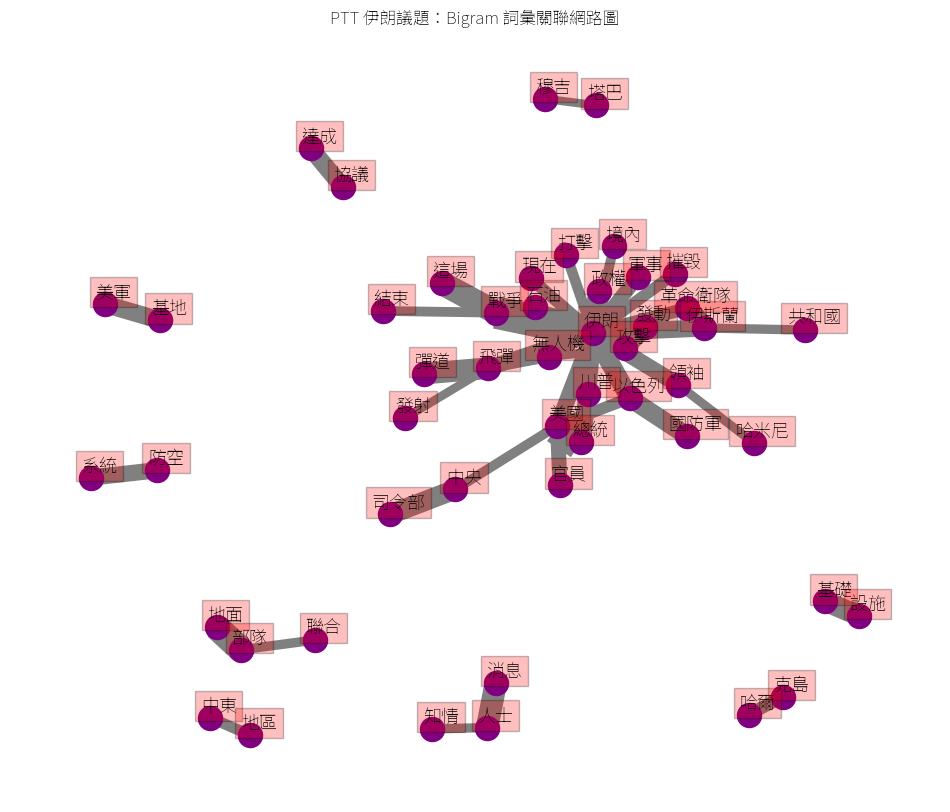

In [28]:
fig, ax = plt.subplots(figsize=(12, 10))

# 設定布局演算法
pos = nx.spring_layout(G, k=1.5)

# 繪製網路基礎線條與節點
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels=False,
                 ax=ax)

# 增加標籤與邊框設定
for key, value in pos.items():
    x, y = value[0] + 0.02, value[1] + 0.02
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.title("PTT 伊朗議題：Bigram 詞彙關聯網路圖")
plt.axis('off')
plt.show()

#### 4. Pairwise correlation

#### 準備相關性分析資料

In [29]:
# 1. 準備資料
ptt_cor_df = word_df.groupby('doc')['word'].apply(lambda x: ' '.join(map(str, x))).reset_index()
ptt_cor_df.columns = ['doc', 'word']

# 2. 建立 DTM
# 這裡加入一個關鍵參數 token_pattern，強制過濾掉長度小於 2 的英文（如 cc, my）
vectorizer = CountVectorizer(
    min_df=5,
    max_features=300,
    token_pattern=r'(?u)\b[^\d\W]{2,}\b' # 只抓長度 2 以上且非數字的詞
)
X = vectorizer.fit_transform(ptt_cor_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 3. 轉成 DataFrame
DTM_df = pd.DataFrame(columns=vocabulary, data=X.toarray())

In [30]:
# 1. 計算詞之間的相關係數 (對 DTM 轉置後計算)
corr_matrix = np.corrcoef(DTM_df.T)

# 2. 轉成 DataFrame 並整理格式
Cor_df = pd.DataFrame(corr_matrix, index=DTM_df.columns, columns=DTM_df.columns)
Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace=True, drop=True)

# 3. 將寬表格轉為長表格 (Melt)
word_cor_df = Cor_df.melt(id_vars='word1', var_name='word2', value_name='cor')

# 4. 去除「自己跟自己相關 (cor=1)」的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

# 5. 去除重複配對
# 透過字串排序比較，確保每組配對只出現一次
word_cor_df = word_cor_df[word_cor_df['word1'] < word_cor_df['word2']]

# 6. 查看結果
print("--- 詞彙相關性排名---")
word_cor_df.sort_values('cor', ascending=False).head(10)

--- 詞彙相關性排名---


,word1,word2,cor
19511,中央,司令部,0.947926
89904,真主黨,黎巴嫩,0.906658
61275,國防軍,真主黨,0.895281
89775,國防軍,黎巴嫩,0.860630
89291,發射,飛彈,0.828091
61224,以色列,真主黨,0.828070
22524,以色列,國防軍,0.825388
69204,真主黨,聲稱,0.814456
82428,聯合,部隊,0.809016
89724,以色列,黎巴嫩,0.789944


#### 4.1 關鍵詞相關性視覺化 (以「伊朗」與「以色列」為例)

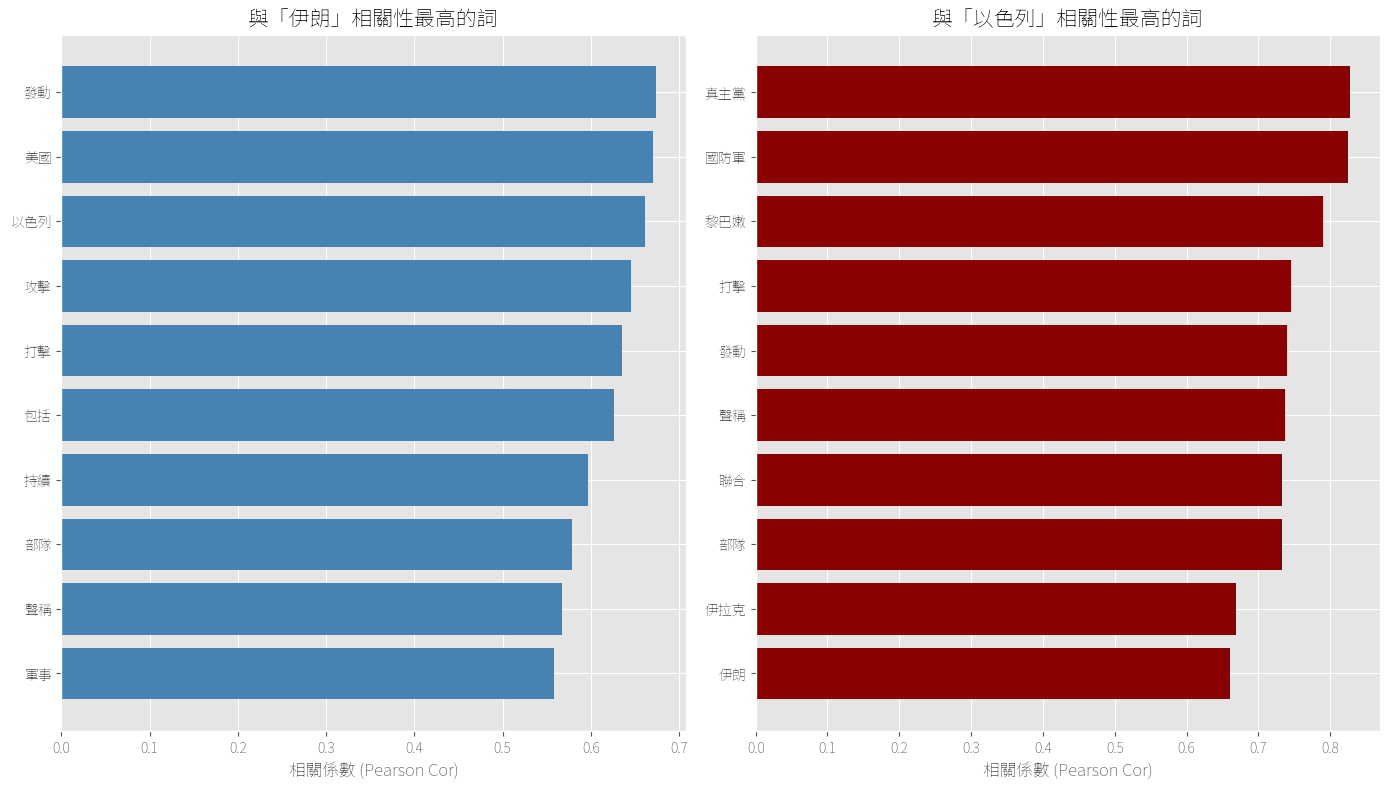

In [31]:
# 定義一個函式來獲取特定詞彙的相關性排行榜
def get_top_correlations(df, target_word, n=10):
    # 1. 篩選出 word1 或 word2 包含目標詞的列
    mask = (df['word1'] == target_word) | (df['word2'] == target_word)
    filtered = df[mask].copy()
    
    # 2. 建立新欄位 'related_word'，把「不是目標詞」的那一邊抓出來
    filtered['related_word'] = filtered.apply(
        lambda x: x['word2'] if x['word1'] == target_word else x['word1'], axis=1
    )
    
    # 3. 排序並取前 n 名
    return filtered.sort_values(by='cor', ascending=False).head(n)

# --- 執行篩選 ---
iran_cor = get_top_correlations(word_cor_df, "伊朗")
israel_cor = get_top_correlations(word_cor_df, "以色列")

# --- 設定繪圖格式 ---
plt.figure(figsize=(14, 8))
plt.style.use("ggplot")

# --- 左圖：伊朗 ---
plt.subplot(121)
plt.title('與「伊朗」相關性最高的詞', fontsize=15, fontweight='bold')
plt.xlabel('相關係數 (Pearson Cor)')
# 注意這裡改用 'related_word'
plt.barh(iran_cor['related_word'], iran_cor['cor'], color="steelblue")
plt.gca().invert_yaxis()

# --- 右圖：以色列 ---
plt.subplot(122)
plt.title('與「以色列」相關性最高的詞', fontsize=15, fontweight='bold')
plt.xlabel('相關係數 (Pearson Cor)')
# 注意這裡改用 'related_word'
plt.barh(israel_cor['related_word'], israel_cor['cor'], color="darkred")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### 4.2 使用詞彙關係圖畫出以詞頻前60為節點且相關性高於0.3的組合

In [32]:
# 1. 透過 DTM 找出詞頻前 60 高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index()
most_freq_df.columns = ['word', 'count']
most_freq_word = most_freq_df['word'].tolist()

# 2. 保留「兩個詞都在前 60 名」且「相關係數 > 0.3」的組合
filtered_df = word_cor_df[
    (word_cor_df['word1'].isin(most_freq_word)) &
    (word_cor_df['word2'].isin(most_freq_word)) &
    (word_cor_df['cor'] > 0.3)
].reset_index(drop=True)

# 檢查一下篩選後的資料量
print(f"篩選後的連結數量：{len(filtered_df)}")
filtered_df.head()

篩選後的連結數量：455


,word1,word2,cor
0,人士,以色列,0.357904
1,中東,伊朗,0.348325
2,人士,伊朗,0.378338
3,以色列,伊朗,0.661057
4,伊朗,協議,0.381432


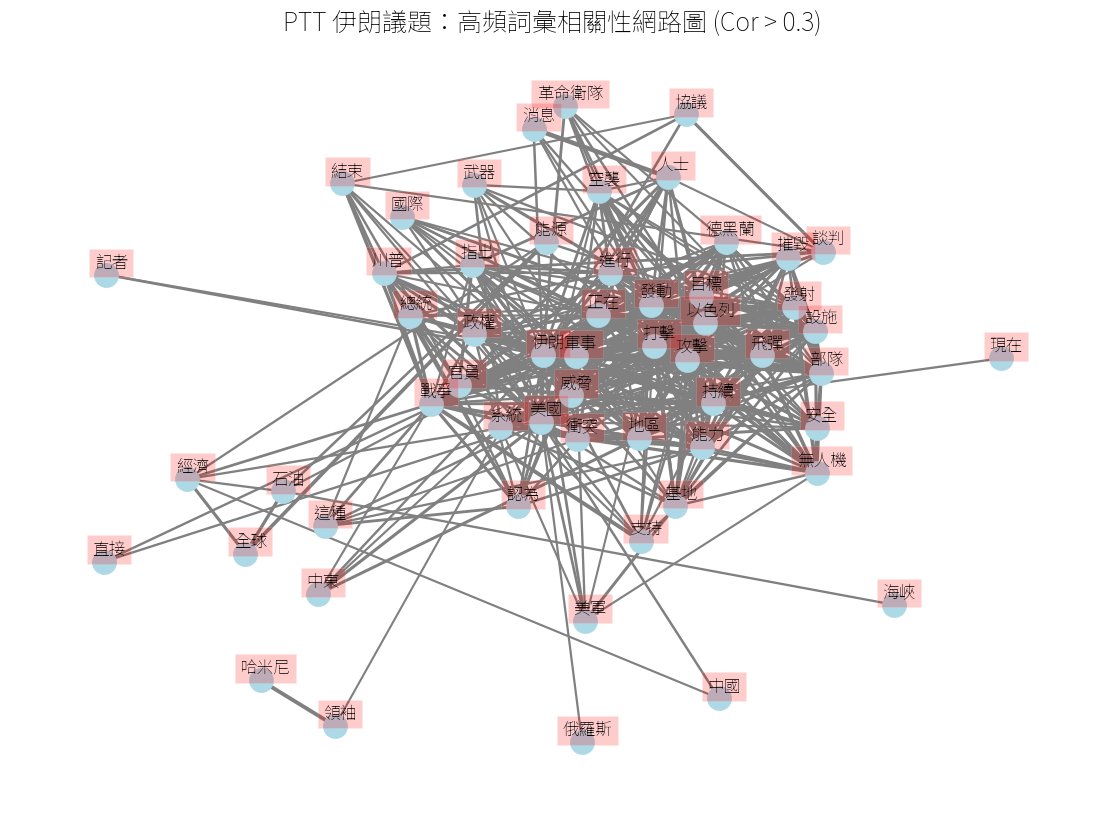

In [33]:
# 1. 建立 Graph 物件
g = nx.Graph()

# 2. 建立節點與連線
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 3. 根據相關係數決定線條粗細 (乘上 5 倍是為了讓差異明顯)
weights = [w[2]['weight'] * 5 for w in g.edges(data=True)]

# 4. 繪製圖形
fig, ax = plt.subplots(figsize=(14, 10))

# k 值決定節點間的斥力
pos = nx.spring_layout(g, k=0.8, seed=42)

# 繪製網路基礎
nx.draw_networkx(g, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels=False,
                 ax=ax)

# 增加標籤與半透明紅底背景
for key, value in pos.items():
    x, y = value[0] + 0.01, value[1] + 0.02
    ax.text(x, y, s=key,
            bbox=dict(facecolor='red', alpha=0.2),
            horizontalalignment='center', fontsize=12)

plt.title("PTT 伊朗議題：高頻詞彙相關性網路圖 (Cor > 0.3)", fontsize=18)
plt.axis('off')
plt.show()

### 5. 計算文章相似度

In [34]:
clean_content = word_df.groupby('doc')['word'].apply(lambda x: ' '.join(map(str, x)))

# 建立一個同步的資料表 (包含標題、網址、內容)
data_cos = df.loc[clean_content.index, ["artTitle", "artUrl"]].copy()
data_cos['word'] = clean_content.values

data_cos = data_cos.reset_index(drop=True)

X = vectorizer.fit_transform(data_cos["word"])

In [35]:
# 1. 將 tfidf 改成 X (對應你上一單元的輸出變數)
cos_df = pd.DataFrame(cosine_similarity(X, X)[0], columns=['cos_similarity'])

# 2. 合併文章資訊
cos_df = cos_df.merge(data_cos, left_index=True, right_index=True)

# 3. 排序看前 10 名
print(f"--- 與第一篇文章《{data_cos.iloc[0]['artTitle']}》最相似的 Top 10 ---")
display(cos_df.sort_values(by=['cos_similarity'], ascending=False).head(10))

--- 與第一篇文章《[新聞] 保護伊朗人員前來　巴基斯坦空軍闢安全》最相似的 Top 10 ---


,cos_similarity,artTitle,artUrl,word
0,1.000000,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,https://www.ptt.cc/bbs/Military/M.1775823165.A...,出處 摘要 中央社 新德里 綜合 外電 美國 伊朗 將於日 巴基斯坦 首都 伊斯蘭 巴德 舉...
1529,0.742307,[問卦] 台灣為什麼不當美國跟伊朗的和事佬,https://www.ptt.cc/bbs/Gossiping/M.1774838868....,最近 美國 伊朗 打起來 協助 調停 巴基斯坦 台灣 不像 巴基斯坦 和事佬 角色
298,0.735631,[新聞] 巴基斯坦：美、伊朗談判「進行中」,https://www.ptt.cc/bbs/Military/M.1774540153.A...,和事佬 出面 證實 巴基斯坦 伊朗 談判 進行 伊朗 一再 否認 美國 談判 結束 戰爭 居...
253,0.643939,[情報] 巴基斯坦外長稱伊朗與美國已同意進行談判,https://www.ptt.cc/bbs/Military/M.1774806708.A...,巴基斯坦 外長 沙克 達爾 巴基斯坦 伊朗 美國 雙方 表達 巴基斯坦 促成 對話 信任 感...
719,0.642931,Re: [情報] 沙烏地要求巴基斯坦加入對伊朗戰爭,https://www.ptt.cc/bbs/Military/M.1772691671.A...,沙國 王儲 要求 巴基斯坦 加入 伊朗 戰爭 取消 沙巴 雙邊 安全 協議 伊朗 真要 這篇...
54,0.639763,[情報] 伊朗證實川普已同意伊朗10點為談判基礎,https://www.ptt.cc/bbs/Military/M.1775605096.A...,伊朗 官方 證實 達成 兩週 停火 協議 指出 川普 同意 伊朗 提出 的點 條件 雙方 後...
14,0.630952,[新聞] 美伊談判生變？伊朗大使刪除伊朗代表團將,https://www.ptt.cc/bbs/Military/M.1775719468.A...,美伊 談判 生變 伊朗 大使 伊朗 代表團 抵達 巴基斯坦 貼文 聯合報 大陸 中心 即時 ...
260,0.625846,[新聞] 巴基斯坦與伊朗達成協議 20艘巴國船隻可,https://www.ptt.cc/bbs/Military/M.1774759027.A...,原文 原文 摘要 中東 戰火 持續 延燒 伊朗 實質 封鎖 荷姆茲海峽 這也 造成 全球 油...
720,0.606161,[情報] 沙烏地要求巴基斯坦加入對伊朗戰爭,https://www.ptt.cc/bbs/Military/M.1772690582.A...,沙國 王儲 要求 巴基斯坦 加入 伊朗 戰爭 取消 沙巴 雙邊 安全 協議 伊朗 真要
986,0.599491,[問卦] 伊朗其實不是落後國家的八卦？,https://www.ptt.cc/bbs/Gossiping/M.1775625857....,伊朗 伊斯蘭 共和國 波斯語 通稱 伊朗 波斯語 外界 稱為 波斯 地處 西亞 伊朗 高原 ...


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

# 關鍵補位：先計算整張相似度矩陣 (這會得到一個 文章數 x 文章數 的矩陣)
cosine_matrix = cosine_similarity(X)

# --- 以下是你原本的觀察程式碼 ---
target_index = 14 # 觀察第 15 篇文章 (Index 從 0 開始)

cos_df_target = pd.DataFrame(cosine_matrix[target_index], columns=['cos_similarity'])
cos_df_target = cos_df_target.merge(data_cos, how='left', left_index=True, right_index=True)

print(f"--- 與第 {target_index} 篇文章最相似的內容 ---")
print(f"目標文章標題：{data_cos.iloc[target_index]['artTitle']}")

# 排序並顯示結果
display(cos_df_target.loc[:,["cos_similarity", "artTitle", "artUrl"]]
        .sort_values(by=['cos_similarity'], ascending=False).head(10))

--- 與第 14 篇文章最相似的內容 ---
目標文章標題：[新聞] 美伊談判生變？伊朗大使刪除伊朗代表團將


,cos_similarity,artTitle,artUrl
14,1.000000,[新聞] 美伊談判生變？伊朗大使刪除伊朗代表團將,https://www.ptt.cc/bbs/Military/M.1775719468.A...
961,0.773237,[問卦] 伊朗是不是打不過以色列啊,https://www.ptt.cc/bbs/Gossiping/M.1775668128....
962,0.758426,[新聞] 快訊》美伊難講和 伊朗威脅退出！,https://www.ptt.cc/bbs/Gossiping/M.1775664939....
939,0.752030,[新聞] 以色列空襲黎巴嫩釀250餘死 伊朗警告再轟,https://www.ptt.cc/bbs/Gossiping/M.1775728228....
23,0.750249,Re: [情報] 伊朗媒體稱以軍繼續轟炸黎巴嫩將導致伊朗退出停火,https://www.ptt.cc/bbs/Military/M.1775673468.A...
2147,0.737022,[問卦] 美吹說伊朗恐怖份子 但支持以色列殺人？,https://www.ptt.cc/bbs/Gossiping/M.1773763072....
987,0.732958,[新聞] 美伊各自宣布大獲全勝！伊朗持續與以色,https://www.ptt.cc/bbs/Gossiping/M.1775625742....
10,0.731247,[情報] 伊朗副外長稱巴基斯坦說服己方別重啟戰端,https://www.ptt.cc/bbs/Military/M.1775757443.A...
20,0.717071,[情報] ISW 伊朗最新情勢特別報告，2026年4月8日,https://www.ptt.cc/bbs/Military/M.1775698357.A...
1213,0.708683,[問卦] 會給伊朗respect的舉手,https://www.ptt.cc/bbs/Gossiping/M.1775303818....


# 二、文件分類（PTT 伊朗議題）


## 目標
- 資料來源：PTT `Gossiping` 與 `Military` 兩個版別
- 研究主題：伊朗相關議題文章
- 任務：根據文章文字內容，預測文章屬於哪一個版別

## 主要步驟
1. 讀入資料來源 `ptt_iran_20260301_0410_full.csv`，並檢查版別分布與日期範圍
2. 清理文字、合併標題與內文、建立 `content`
3. 使用 jieba 斷詞並移除停用字，建立 `words`
4. 以 7:3 切分 train/test，建立 `CountVectorizer` 與 `TfidfVectorizer`
5. 先示範 Logistic Regression 的基本分類流程，再用 `classification_report` 與混淆矩陣評估
6. 使用 cross-validation 檢查模型穩定度
7. 比較多個分類器，選出表現最佳的模型
8. 用 Logistic Regression 係數觀察可解釋特徵
9. 使用 held-out test set 分析最佳模型的錯誤分類結果


## 1. 套件說明
- conda activate SMA2026
- `pandas`：整理表格資料與摘要統計
- `jieba`：中文斷詞
- `sklearn`：向量化、分類模型、cross-validation、模型評估
- `matplotlib` / `seaborn`：資料視覺化與混淆矩陣繪圖


In [37]:
import re
from pathlib import Path
from pprint import pprint

import jieba
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager as fm
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 777
BASE_DIR = Path.cwd()
DICT_DIR = BASE_DIR.parent / 'dict'
DATA_DIR = BASE_DIR.parent / 'data'

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

設定中文字體

In [38]:
font_path = BASE_DIR / 'font.ttf'
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
else:
    font_name = 'Arial Unicode MS'

plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
print(f'using font: {font_name}')

using font: Noto Sans TC


## 2. 文字前處理
本節對應範例，先讀入原始資料並檢查資料狀況，再完成清理、合併文字與斷詞。

- 資料來源：`ptt_iran_20260301_0410_full.csv`

In [39]:
# 讀取原始 PTT 資料，並建立 summarize_raw_dataset() 函式檢查資料筆數、重複網址、缺值與日期範圍。
# 這一格的輸出 raw_summary 可以用來確認資料是否完整、是否有重複文章，以及標籤欄位是否有缺失。

full_raw = pd.read_csv(DATA_DIR / 'ptt_iran_20260301_0410_full.csv')


# 定義一個摘要函式，用來檢查原始資料集的品質
def summarize_raw_dataset(df, dataset_name):
    # 將文章日期轉成 datetime，無法轉換者會變成 NaT
    art_date = pd.to_datetime(df['artDate'], errors='coerce')
    return {
        'dataset': dataset_name,
        'rows': len(df),
        'unique_urls': df['artUrl'].nunique(dropna=True),
        'duplicate_urls': df['artUrl'].duplicated().sum(),
        'missing_label': df['artCatagory'].isna().sum(),
        'missing_title': df['artTitle'].isna().sum(),
        'missing_content': df['artContent'].isna().sum(),
        'date_min': art_date.min(),
        'date_max': art_date.max(),
    }


# 將摘要結果整理成 DataFrame，方便在 notebook 中以表格呈現
raw_summary = pd.DataFrame([
    summarize_raw_dataset(full_raw, 'ptt_iran_20260301_0410_full.csv'),
])

display(raw_summary)


,dataset,rows,unique_urls,duplicate_urls,missing_label,missing_title,missing_content,date_min,date_max
0,ptt_iran_20260301_0410_full.csv,3547,3547,0,0,0,0,2026-03-01 00:01:58,2026-04-10 22:02:53


從上表可以檢查完整資料集的文章數、重複網址、缺值狀況與日期範圍。

In [40]:
# 預覽原始資料前三筆，快速確認欄位名稱與內容格式。

full_raw.head(3)


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,wysptt,Military,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/202604100193.aspx\r\n\r\n新聞內容摘要：\r\n（中央社新德里10日綜合外電報導）美國與伊朗將於11日在巴基斯坦首都伊斯蘭馬...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tony121010"", ""cmtContent"": "": 那麼多石油王，他們會出啦"", ""cmtDate"": ""2026-04-10 20:13:00""}, {""...",2026-04-13 22:25:19,ptt
1,2,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,[情報] 幾則關於伊朗戰爭的民調,2026-04-10 16:20:52,jimmy5680,Military,https://x.com/NateSilver538/status/2039839743404363863\r\n根據Nate Silver的統整各間民調，\r\n可見美國民眾對伊朗戰爭的支持度持續下滑\r\nhttps://pb...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""MarchelKaton"", ""cmtContent"": "": 川普還嗆右派名嘴不是MAGA自己人了"", ""cmtDate"": ""2026-04-10 17:53:...",2026-04-13 22:25:19,ptt
2,3,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,2026-04-10 15:54:15,jimmy5680,Military,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry/status/2042217021010571332\r\nhttps://t.co/e88nkwJ8hQ\r\n\r\n中國從伊朗戰爭中...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""jinkela1"", ""cmtContent"": "": 可寫一整篇回文 但總而言之 台灣情況和伊朗天差地別"", ""cmtDate"": ""2026-04-10 15:...",2026-04-13 22:25:20,ptt


In [41]:
# 統計 artCatagory 欄位的類別分布，檢查 Gossiping、Military 以及缺失值各有多少筆。

label_preview = full_raw['artCatagory'].value_counts(dropna=False).to_frame(name='full_raw')

label_preview


,full_raw
artCatagory,
Gossiping,2616
Military,931


### 2.1 清理
會沿用已出現的 PTT 專屬清理邏輯。

處理重點：
- 移除缺少標題、內文或版別的資料
- 移除重複 `artUrl`
- 清掉網址、PTT 發信站資訊、引述、回文標籤與雜訊符號
- 合併 `artTitle` 與 `artContent` 成新的 `content`


In [42]:
# 建立文字前處理流程：自訂詞、同義詞、停用詞、PTT 文字清理、jieba 斷詞、資料整理與混淆矩陣繪圖函式。
# 這一格是後續分類模型的核心前處理設定，會把原始文章轉成模型可以使用的 words 欄位。

# 自訂專有名詞，讓 jieba 不會把重要詞彙切得太碎
custom_words = [
    '防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東',
    '大馬士革', '德黑蘭', '哈梅內伊', '哈米尼', '霍爾木茲海峽',
    '荷姆茲海峽', '荷莫茲海峽'
]

# 同義詞統一表：把不同寫法轉成同一個標準詞
synonyms = {
    '哈梅內伊': '哈米尼',
    '霍爾木茲': '荷姆茲',
    '荷莫茲': '荷姆茲',
    '阿川': '川普',
    '川皇': '川普',
}

# 手動停用詞：移除常見但對分類幫助不大的 PTT 用語與雜訊詞
manual_stopwords = {
    '-----', '----', '連結', '嘖嘖', '醒醒', '裝睡', '衛生紙', '乳摸', '高潮',
    '新聞', '內文', '備註', '刪除', '完整', '轉載', '編輯', '張貼', '署名',
    '文章', '標題', '報導', '八卦', '看板', '作者', '時間', '來源', '內容',
    '媒體', '情況', '問題', '如題', '原因', '網址', '發信', '實業', 'cc',
    'ptt', 'gossiping', 'www', 'com', 'https', 'http', 'share', 'url', 'index',
    'html', 'bbs', 'status', '表示', '行動', '國家', '當作', '出現', '晚間',
    '政府', '目前', '請放', '最後', '違者', '未滿', '繁體', '中文字', '水桶',
    '一天', '以天', '單位', '網友', '點擊', '情報', '分享', '問卦', '討論',
    '心得', '爆卦'
}

# 載入 jieba 字典與使用者自訂詞典
jieba.set_dictionary(str(DICT_DIR / 'dict.txt'))
jieba.load_userdict(str(DICT_DIR / 'user_dict.txt'))
for word in custom_words:
    jieba.add_word(word)

stopwords = []
for stopword_file in [DICT_DIR / 'stopwords.txt', DICT_DIR / 'text_stopwords.txt']:
    with open(stopword_file, encoding='utf-8') as f:
        stopwords.extend([line.strip() for line in f if line.strip()])
stopwords = set(stopwords) | manual_stopwords


# 清理 PTT 原文，只保留適合中文斷詞與建模的主要文字
def clean_ptt_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'※\s*(發信站|文章網址|編輯).*', '', text)
    text = re.sub(r'引述《.*?》之銘言', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    text = re.sub(r'[-/=_~]{2,}', '', text)
    text = re.sub(r'[^\u4e00-\u9fa5\n]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# 將清理後文字斷詞，並移除停用詞與過短詞
def getToken(text):
    tokens = []
    for word in jieba.lcut(text):
        word = synonyms.get(word, word).strip()
        if len(word) >= 2 and word not in stopwords:
            tokens.append(word)
    return tokens


# 將原始 PTT 資料整理成模型可用的文件資料表
def prepare_ptt_documents(df, drop_missing_label=True):
    data = df[['artUrl', 'artTitle', 'artContent', 'artCatagory', 'artDate']].copy()
    subset = ['artTitle', 'artContent'] + (['artCatagory'] if drop_missing_label else [])
    data = data.dropna(subset=subset)
    data = data.drop_duplicates(subset='artUrl').copy()
    data['artDate'] = pd.to_datetime(data['artDate'], errors='coerce')
    data['title_clean'] = data['artTitle'].map(clean_ptt_text)
    data['content_clean'] = data['artContent'].map(clean_ptt_text)
    data['content'] = (data['title_clean'] + ' ' + data['content_clean']).str.strip()
    data['words'] = data['content'].apply(getToken).map(' '.join)
    data = data[data['words'].str.len() > 0].copy()
    return data


# 繪製混淆矩陣，用來觀察模型的正確與錯誤分類情況
def plot_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues, cbar=False, ax=ax)
    ax.set(
        xlabel='Pred',
        ylabel='True',
        xticklabels=classes,
        yticklabels=classes,
        title=title,
    )
    plt.yticks(rotation=0)
    plt.show()
    return cm

Building prefix dict from C:\Users\justi\OneDrive\文件\中山碩士\社媒\Social_Network_Analysis_Group_3-main\groupwork2\dict\dict.txt ...
Loading model from cache C:\Users\justi\AppData\Local\Temp\jieba.u8028ad36b404e2a685691e04a294fe4e.cache
Loading model cost 0.392 seconds.
Prefix dict has been built successfully.


文章的標題 `artTitle` 和內文 `artContent` 都會納入分析內容，並保留 `artUrl` 與 `artCatagory` 供後續建模與比對使用。

In [43]:
# 呼叫 prepare_ptt_documents() 清理完整資料集，並將清理後的 full_docs 複製成 train_docs 供後續模型使用。
# clean_summary 用來檢查清理後剩下多少文章、日期範圍，以及兩個分類的資料量。

full_docs = prepare_ptt_documents(full_raw, drop_missing_label=True)

# 本版 notebook 只使用 0410_full.csv。
# 為了讓後續建模流程維持原本寫法，直接把清理後的 full_docs 作為 train_docs 使用。
train_docs = full_docs.copy()

clean_summary = pd.DataFrame([
    {
        'dataset': 'train_docs_from_0410_full',
        'rows_after_clean': len(train_docs),
        'date_min': train_docs['artDate'].min(),
        'date_max': train_docs['artDate'].max(),
        'Gossiping': (train_docs['artCatagory'] == 'Gossiping').sum(),
        'Military': (train_docs['artCatagory'] == 'Military').sum(),
    }
])

display(clean_summary)


,dataset,rows_after_clean,date_min,date_max,Gossiping,Military
0,train_docs_from_0410_full,3547,2026-03-01 00:01:58,2026-04-10 22:02:53,2616,931


In [44]:
# 預覽清理後的文章資料，確認 content 是清理後全文，words 是斷詞後的模型輸入文字。

train_docs[['artDate', 'artCatagory', 'artTitle', 'content', 'words']].head(3)

,artDate,artCatagory,artTitle,content,words
0,2026-04-10 20:12:41,Military,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,保護伊朗人員前來 巴基斯坦空軍闢安全 新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 ...,保護 伊朗 人員 前來 巴基斯坦 空軍 安全 出處 摘要 中央社 新德里 綜合 外電 美國 伊朗 將於日 巴基斯坦 首都 伊斯蘭 巴德 舉行 萬眾矚目 談判 外媒 披露 巴基斯坦 空軍 出動 大批 軍機 波斯灣 空域 保護 伊朗 代...
1,2026-04-10 16:20:52,Military,[情報] 幾則關於伊朗戰爭的民調,幾則關於伊朗戰爭的民調 根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世...,幾則 伊朗 戰爭 民調 統整 各間 民調 美國 民眾 伊朗 戰爭 支持度 持續 下滑 民調 追蹤 美國 民眾 以色列 納坦雅胡 支持度 顯示 美國 民眾 越來越 厭惡 以色列 納坦雅胡 天空 民調 顯示 去年 年底 現在 英國 民眾...
2,2026-04-10 15:54:15,Military,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,大西洋期刊 中國從伊朗戰爭學到什麼 大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限...,大西洋 期刊 中國 伊朗 戰爭 學到 大西洋 期刊 這篇 不予置評 參考 中國 伊朗 戰爭 中學 台灣 實施 封鎖 全球 經濟 造成 衝擊 將比 伊朗 封鎖 荷姆茲海峽 嚴重 中國 這場 伊朗 戰爭 中學 美國 劃下 紅線 期限 伴...


### 2.2 斷詞
使用專案字典、使用者字典、停用字與已整理過的同義詞規則。

In [45]:
# 只查看分類標籤與斷詞結果，方便檢查各類文章的關鍵詞是否合理。

train_docs[['artCatagory', 'words']].head(5)

,artCatagory,words
0,Military,保護 伊朗 人員 前來 巴基斯坦 空軍 安全 出處 摘要 中央社 新德里 綜合 外電 美國 伊朗 將於日 巴基斯坦 首都 伊斯蘭 巴德 舉行 萬眾矚目 談判 外媒 披露 巴基斯坦 空軍 出動 大批 軍機 波斯灣 空域 保護 伊朗 代...
1,Military,幾則 伊朗 戰爭 民調 統整 各間 民調 美國 民眾 伊朗 戰爭 支持度 持續 下滑 民調 追蹤 美國 民眾 以色列 納坦雅胡 支持度 顯示 美國 民眾 越來越 厭惡 以色列 納坦雅胡 天空 民調 顯示 去年 年底 現在 英國 民眾...
2,Military,大西洋 期刊 中國 伊朗 戰爭 學到 大西洋 期刊 這篇 不予置評 參考 中國 伊朗 戰爭 中學 台灣 實施 封鎖 全球 經濟 造成 衝擊 將比 伊朗 封鎖 荷姆茲海峽 嚴重 中國 這場 伊朗 戰爭 中學 美國 劃下 紅線 期限 伴...
3,Military,以色列 軍方 認為 伊朗 以色列 以色列 軍方 告訴 國會 議員 伊朗 戰前 以色列 軍方 另稱 作戰 伊朗 造成 嚴重 打擊 伊朗 著手 恢復 飛彈 生產 能力 肖像 掛在 辦公室 掛上 孩子 照片 決定 看看 眼睛
4,Military,曾嗆 發展 核武 伊朗 外長 傷重 不治 揚言 發展 核武 伊朗 外長 拉齊 遇襲 住所 攻擊 罹難 伊朗 伊朗 外交部長 哈拉 美國 以色列 空襲 受傷 今天 傷重 不治 哈拉 德黑蘭 尋求 發展 核武 法新社 哈拉 濟生 隸屬於...


### 2.3 資料集基本檢視
先確認清理後可用於分類的文章數與版別分布。

total posts: 3547
date range: 2026-03-01 00:01:58 ~ 2026-04-10 22:02:53
category count:
artCatagory
Gossiping    2616
Military      931
Name: count, dtype: int64


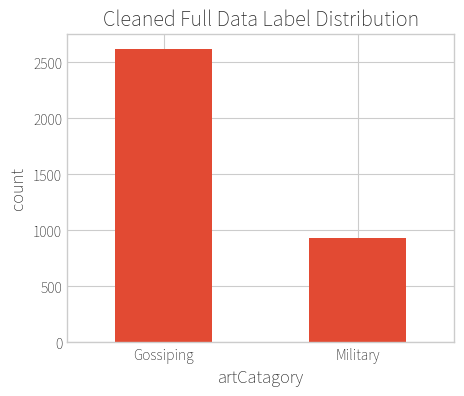

In [46]:
# 輸出清理後的文章數、日期範圍與類別筆數。
# 長條圖用來視覺化類別分布，確認資料是否有明顯不平衡。

print(f"total posts: {len(train_docs['artUrl'].unique())}")
print(f"date range: {train_docs['artDate'].min()} ~ {train_docs['artDate'].max()}")
print('category count:')
print(train_docs['artCatagory'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
train_docs['artCatagory'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Cleaned Full Data Label Distribution')
ax.set_xlabel('artCatagory')
ax.set_ylabel('count')
plt.xticks(rotation=0)
plt.show()


## 3. 分類模型的訓練流程
以 Logistic Regression 分類流程，再比較不同文字表示方式與評估方法。

In [47]:
# 設定模型輸入 X 與答案 y，並使用 train_test_split 切成訓練集與測試集。
# stratify=y 會讓訓練集與測試集維持接近原始資料的類別比例。

data = train_docs.copy()
# X 是輸入特徵：斷詞後的文章文字
X = data['words']
# y 是預測目標：文章所屬看板分類
y = data['artCatagory']

# 將資料分成訓練集與測試集，測試集比例為 30%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(X_train.head())
print(y_train.head())

2704    伊朗 無人機 烏俄 戰爭 俄國 戰車 打爆 現在 烏克蘭 頭痛 伊朗 無人機 以前 一部 影片 底迪 哈米尼 殉教 哈米尼 回答 八十歲 考慮 哈米尼 只差 講出 真心話 現在 無人機 殉教 成本 極低 台萬 伊朗 以前 軍工 大國...
1603    美國 疑在 伊朗 附近 村莊 投反 戰車 地雷 記者 美國 疑在 伊朗 附近 村莊 投反 戰車 地雷 分析師 開源 研究 組織 週四 指出 美國 伊朗 南部 村莊 投下 戰車 地雷 此前 社群 流傳 影像 似乎 顯示 拉子 南部 郊...
2205    伊朗 根本 鄰居 縱火 瓦斯桶 亂炸 鄰居 美軍 基地 以外 知道 真正 搞事 魷魚 魷魚 滅國 老美 輸血 魷魚 有產 石油 還能 源源不絕 挑事 免費 裝備 伊斯蘭 兄弟 老美 沆瀣一氣 美元 魷魚 輸血 血袋 魷魚 表兄弟 伊...
3449    杜拜 機場 伊朗 自殺 無人機 攻擊 女滿 杜拜 機場 伊朗 自殺 無人機 攻擊 女滿 臉血 逃命 畫面 曝光 聯合 新聞網 聯合報 編譯 盧思綸 即時 杜拜 機場 多名 人員 受傷 擷自 影音 每日 郵報 美國 以色列 伊朗 發動...
1278    伊朗 打完 投資 伊朗 打贏 美帝 直接 世界 強權 掌控 世界 石油 出口 世界 向來 贏幫 伊朗 多數 能力 半信半疑 現在 戰成 以後 世界 搶著 打好 關係 幫忙 重建 伊朗 戰後 值得 投資 沒人敢 制裁 石油 制裁 美帝...
Name: words, dtype: object
2704    Gossiping
1603    Gossiping
2205    Gossiping
3449    Gossiping
1278    Gossiping
Name: artCatagory, dtype: object


In [48]:
# 比較原始資料、訓練集與測試集的類別百分比，檢查切分後是否仍維持類別比例。

print('raw data percentage:')
print((data['artCatagory'].value_counts(normalize=True) * 100).round(2))
print('\ntrain percentage:')
print((y_train.value_counts(normalize=True) * 100).round(2))
print('\ntest percentage:')
print((y_test.value_counts(normalize=True) * 100).round(2))

raw data percentage:
artCatagory
Gossiping    73.75
Military     26.25
Name: proportion, dtype: float64

train percentage:
artCatagory
Gossiping    73.77
Military     26.23
Name: proportion, dtype: float64

test percentage:
artCatagory
Gossiping    73.71
Military     26.29
Name: proportion, dtype: float64


### 3.2 將文章轉為 DTM
DTM（document-term matrix）

- `CountVectorizer`：以詞頻表示文章
- `TfidfVectorizer`：以 TF-IDF 權重表示文章

使用 `CountVectorizer + LogisticRegression` 流程。

In [49]:
# 建立 CountVectorizer，把文章轉成詞頻矩陣；max_features=1000 表示最多保留 1000 個詞作為特徵。

count_vectorizer = CountVectorizer(max_features=1000)
print(count_vectorizer)

CountVectorizer(max_features=1000)


In [50]:
# 用訓練資料 fit CountVectorizer 並轉換成詞頻矩陣。
# 再轉成 DataFrame 預覽前幾篇文章在前 20 個特徵詞上的出現次數。

vec_train_count = count_vectorizer.fit_transform(X_train)
count_vocab = count_vectorizer.get_feature_names_out()
count_df = pd.DataFrame(vec_train_count.toarray(), columns=count_vocab)
count_df.iloc[:5, :20]

,一下,一份,一位,一名,一堆,一場,一座,一枚,一架,一次,一段,一直,一種,一致,一艘,一處,一部分,一項,一點,三日
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [51]:
# 用已經 fit 好的 CountVectorizer 轉換測試集，並印出訓練矩陣與測試矩陣的形狀。

vec_test_count = count_vectorizer.transform(X_test)
print(vec_train_count.shape)
print(vec_test_count.shape)

(2482, 1000)
(1065, 1000)


In [52]:
# 建立並訓練 Logistic Regression 模型，使用 CountVectorizer 產生的詞頻特徵做分類。

count_logistic = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
count_logistic.fit(vec_train_count, y_train)
count_logistic


LogisticRegression(max_iter=2000, random_state=777)

In [53]:
# 查看模型學到的類別順序；這個順序會影響 predict_proba 機率欄位的對應類別。

count_logistic.classes_

array(['Gossiping', 'Military'], dtype=object)

使用 train set 訓練後，再用 test set 查看模型的分類結果。

In [54]:
# 用 CountVectorizer + Logistic Regression 預測測試集，並取得每筆文章屬於各類別的預測機率。

y_pred_count = count_logistic.predict(vec_test_count)
y_pred_proba_count = count_logistic.predict_proba(vec_test_count)
print(y_pred_count[:10])

['Gossiping' 'Gossiping' 'Military' 'Gossiping' 'Gossiping' 'Gossiping'
 'Military' 'Military' 'Military' 'Gossiping']


觀察看看模型輸出的類別機率。

In [55]:
# 查看預測機率矩陣大小，並顯示第一篇測試文章對每個類別的預測機率。

print(y_pred_proba_count.shape)
pd.Series(y_pred_proba_count[0], index=count_logistic.classes_)

(1065, 2)


Gossiping    0.998059
Military     0.001941
dtype: float64

### 3.3 模型評估
使用 `classification_report` 與混淆矩陣檢查 `CountVectorizer + LogisticRegression` 的表現。

In [56]:
# 輸出 classification_report，觀察 precision、recall、f1-score 與整體 accuracy。

print(classification_report(y_test, y_pred_count))

              precision    recall  f1-score   support

   Gossiping       0.88      0.92      0.90       785
    Military       0.74      0.64      0.68       280

    accuracy                           0.85      1065
   macro avg       0.81      0.78      0.79      1065
weighted avg       0.84      0.85      0.84      1065



混淆矩陣（Confusion Matrix）可以更直接觀察模型在哪一個版別上較容易分錯。

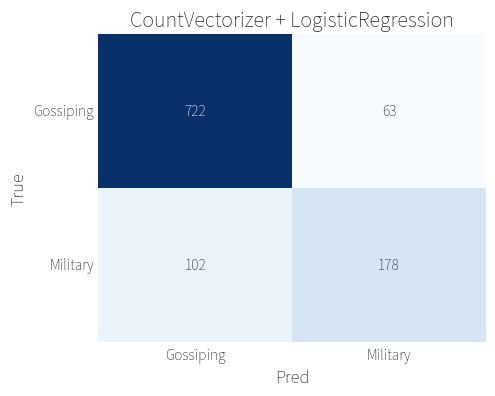

array([[722,  63],
       [102, 178]], dtype=int64)

In [57]:
# 繪製 CountVectorizer + Logistic Regression 的混淆矩陣，觀察哪些類別容易被分錯。

classes = list(count_logistic.classes_)
cm_count = plot_confusion(y_test, y_pred_count, classes, 'CountVectorizer + LogisticRegression')
cm_count

### 3.4 TF-IDF
接著改用 `TfidfVectorizer`，比較和純詞頻 DTM 的差異。

In [58]:
# 建立 TF-IDF 向量器，將文字轉成 TF-IDF 權重矩陣。
# TF-IDF 會降低太常見詞的影響，凸顯更能區分類別的詞。

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
vec_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
vec_test_tfidf = tfidf_vectorizer.transform(X_test)
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(vec_train_tfidf.toarray(), columns=tfidf_vocab)
tfidf_df.iloc[:5, :20]

,一下,一份,一位,一名,一堆,一場,一座,一枚,一架,一次,一段,一直,一種,一致,一艘,一處,一部分,一項,一點,三日
0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.02538,0.000000,0.0,0.0,0.0,0.029888,0.0,0.024014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.00000,0.088839,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
# 使用 TF-IDF 特徵訓練 Logistic Regression，並在測試集上輸出分類表現。

tfidf_logistic = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
tfidf_logistic.fit(vec_train_tfidf, y_train)
y_pred_tfidf = tfidf_logistic.predict(vec_test_tfidf)
y_pred_proba_tfidf = tfidf_logistic.predict_proba(vec_test_tfidf)

print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

   Gossiping       0.85      0.97      0.91       785
    Military       0.86      0.53      0.65       280

    accuracy                           0.85      1065
   macro avg       0.86      0.75      0.78      1065
weighted avg       0.85      0.85      0.84      1065



### 3.5 Cross Validation
用 `TfidfVectorizer + LogisticRegression` 檢查 5-fold CV 的整體穩定度。

In [60]:
# 在訓練集內進行 5-fold cross validation，評估 Logistic Regression 的穩定性。
# cv_summary 會整理每個評估指標的平均值與標準差。

cv_logistic = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
cv_train_matrix = TfidfVectorizer(max_features=1000).fit_transform(X_train)

cv_scores = cross_validate(
    cv_logistic,
    cv_train_matrix,
    y_train,
    cv=5,
    scoring=('accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted'),
    return_train_score=False,
)

cv_summary = pd.DataFrame(cv_scores).agg(['mean', 'std']).T
cv_summary

,mean,std
fit_time,0.007973,0.001747
score_time,0.011227,0.002389
test_accuracy,0.837621,0.028023
test_f1_weighted,0.819211,0.034566
test_precision_weighted,0.838541,0.036190
test_recall_weighted,0.837621,0.028023


`cross_val_predict()` 會回傳每一筆訓練資料在 cross-validation 下得到的預測類別。

In [61]:
# 使用 cross_val_predict 取得每筆訓練資料的交叉驗證預測結果，並輸出分類報告。

y_pred_cv = cross_val_predict(cv_logistic, cv_train_matrix, y_train, cv=5)
print(classification_report(y_train, y_pred_cv))

              precision    recall  f1-score   support

   Gossiping       0.84      0.97      0.90      1831
    Military       0.85      0.46      0.60       651

    accuracy                           0.84      2482
   macro avg       0.84      0.72      0.75      2482
weighted avg       0.84      0.84      0.82      2482



## 4. 比較不同模型效果
這一節對應範例 week7 的第 4 節，固定使用 `TfidfVectorizer(max_features=1000)`，比較 Logistic Regression、Decision Tree、SVM 與 Random Forest。

In [62]:
# 定義 train_cv_experiment()：把向量化、交叉驗證、分類報告、混淆矩陣與最終模型訓練包成同一個流程。
# 這個函式後面會被用來比較不同分類模型。

# 定義通用實驗函式，讓不同模型可以用同一套流程比較
def train_cv_experiment(vectorizer, clf, X, y, model_name, cv=5):
    # 將文字轉換成數值矩陣，作為機器學習模型的輸入
    vec_X = vectorizer.fit_transform(X).toarray()
    # 使用交叉驗證取得每筆資料的 out-of-fold 預測結果
    y_pred_cv = cross_val_predict(clf, vec_X, y, cv=cv)
    cls_report = classification_report(y, y_pred_cv, output_dict=True)
    print(f'===== {model_name} =====')
    print(classification_report(y, y_pred_cv))
    plot_confusion(y, y_pred_cv, sorted(pd.Series(y).unique()), f'{model_name} CV Confusion Matrix')
    # 用完整訓練資料重新訓練模型，方便後續拿去預測測試集
    clf.fit(vec_X, y)
    return {
        'report': cls_report,
        'model': clf,
        'vectorizer': vectorizer,
        'cv_pred': y_pred_cv,
    }

===== clf_logistic =====
              precision    recall  f1-score   support

   Gossiping       0.84      0.97      0.90      1831
    Military       0.85      0.46      0.60       651

    accuracy                           0.84      2482
   macro avg       0.84      0.72      0.75      2482
weighted avg       0.84      0.84      0.82      2482



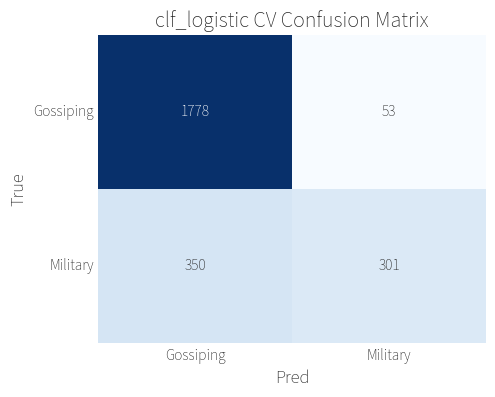

===== clf_dtree =====
              precision    recall  f1-score   support

   Gossiping       0.84      0.85      0.85      1831
    Military       0.56      0.55      0.56       651

    accuracy                           0.77      2482
   macro avg       0.70      0.70      0.70      2482
weighted avg       0.77      0.77      0.77      2482



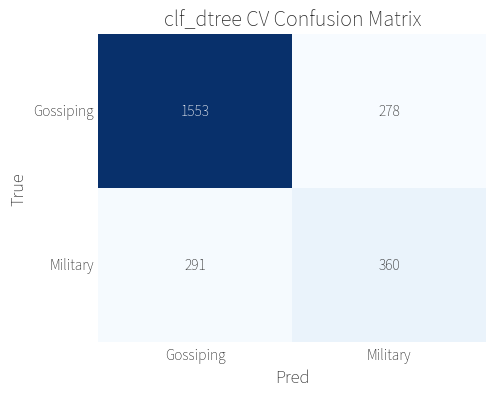

===== clf_svm =====
              precision    recall  f1-score   support

   Gossiping       0.84      0.97      0.90      1831
    Military       0.84      0.49      0.62       651

    accuracy                           0.84      2482
   macro avg       0.84      0.73      0.76      2482
weighted avg       0.84      0.84      0.83      2482



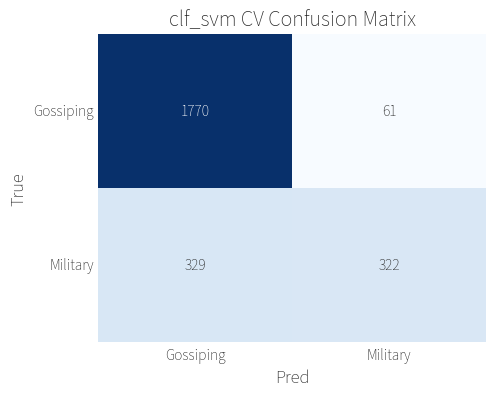

===== clf_rf =====
              precision    recall  f1-score   support

   Gossiping       0.84      0.98      0.90      1831
    Military       0.88      0.47      0.61       651

    accuracy                           0.84      2482
   macro avg       0.86      0.72      0.76      2482
weighted avg       0.85      0.84      0.83      2482



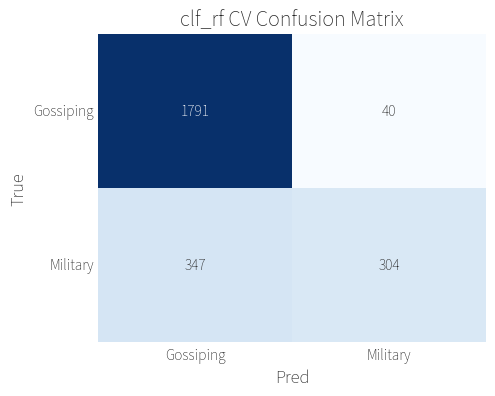

In [63]:
# 建立四種模型並逐一進行 TF-IDF + cross validation 實驗，比較 Logistic Regression、Decision Tree、SVM、Random Forest。

model_set = {
    'clf_logistic': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'clf_dtree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'clf_svm': svm.SVC(probability=True, random_state=RANDOM_STATE),
    'clf_rf': RandomForestClassifier(random_state=RANDOM_STATE),
}

result_set = {}
for model_name, model in model_set.items():
    result_set[model_name] = train_cv_experiment(
        TfidfVectorizer(max_features=1000),
        model,
        X_train,
        y_train,
        model_name,
        cv=5,
    )

分別觀察各個分類模型在 weighted avg 指標上的整體表現。

In [64]:
# 把各模型的 cross validation 結果整理成表格，並依 weighted f1-score 由高到低排序。

model_summary = pd.DataFrame([
    {
        'model': model_name,
        'accuracy': result['report']['accuracy'],
        'precision_weighted': result['report']['weighted avg']['precision'],
        'recall_weighted': result['report']['weighted avg']['recall'],
        'f1_weighted': result['report']['weighted avg']['f1-score'],
        'f1_macro': result['report']['macro avg']['f1-score'],
    }
    for model_name, result in result_set.items()
]).sort_values(by='f1_weighted', ascending=False)

model_summary

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
2,clf_svm,0.842869,0.842596,0.842869,0.827863,0.761794
3,clf_rf,0.844077,0.849770,0.844077,0.826053,0.756775
0,clf_logistic,0.837631,0.839397,0.837631,0.819729,0.748606
1,clf_dtree,0.770749,0.769294,0.770749,0.769999,0.701871


找出 `weighted avg f1-score` 表現最好的模型。

In [65]:
# 取出表現最好的模型名稱與完整結果，並列印最佳模型的分類報告字典。

best_model_name = model_summary.iloc[0]['model']
best_result = result_set[best_model_name]

print(f'best model: {best_model_name}')
pprint(best_result['report'])

best model: clf_svm
{'Gossiping': {'f1-score': 0.9007633587786259,
               'precision': 0.8432586946164841,
               'recall': 0.9666848716548334,
               'support': 1831.0},
 'Military': {'f1-score': 0.6228239845261122,
              'precision': 0.8407310704960835,
              'recall': 0.4946236559139785,
              'support': 651.0},
 'accuracy': 0.8428686543110395,
 'macro avg': {'f1-score': 0.761793671652369,
               'precision': 0.8419948825562837,
               'recall': 0.730654263784406,
               'support': 2482.0},
 'weighted avg': {'f1-score': 0.8278630635979706,
                  'precision': 0.8425957279354281,
                  'recall': 0.8428686543110395,
                  'support': 2482.0}}


              precision    recall  f1-score   support

   Gossiping       0.86      0.98      0.91       785
    Military       0.90      0.55      0.68       280

    accuracy                           0.86      1065
   macro avg       0.88      0.76      0.80      1065
weighted avg       0.87      0.86      0.85      1065



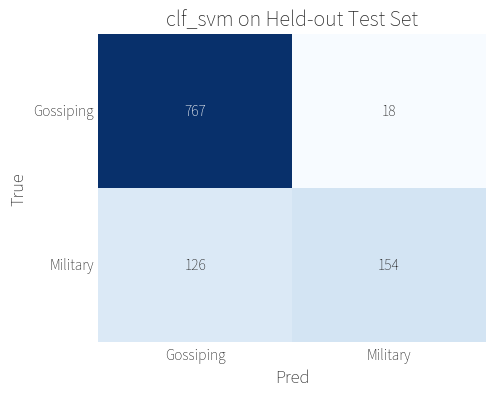

array([[767,  18],
       [126, 154]], dtype=int64)

In [66]:
# 使用最佳模型預測保留的測試集，輸出 classification_report 並繪製測試集混淆矩陣。

best_model = best_result['model']
best_vectorizer = best_result['vectorizer']

y_pred_best_test = best_model.predict(best_vectorizer.transform(X_test).toarray())
print(classification_report(y_test, y_pred_best_test))
plot_confusion(y_test, y_pred_best_test, sorted(y_test.unique()), f'{best_model_name} on Held-out Test Set')

## 5. 分析可解釋模型的結果
雖然的最佳模型不一定是 Logistic Regression，但 Logistic Regression 的係數最容易解釋，因此仍沿用範例 notebook 的做法，用 `TfidfVectorizer + LogisticRegression` 觀察字詞特徵。

In [67]:
# 定義 plot_coef()，用 Logistic Regression 的係數找出最能推動各類別判斷的關鍵詞。
# 係數越大代表該詞越會把文章推向該類別；係數越小則代表越不支持該類別。

# 定義係數視覺化函式，找出 Logistic Regression 最重視的關鍵詞
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    # 二元分類時 sklearn 只會存一組係數，另一類可視為相反方向
    if len(logistic_reg_model.classes_) == 2:
        coef_df = pd.DataFrame(
            {
                logistic_reg_model.classes_[0]: -logistic_reg_model.coef_[0],
                logistic_reg_model.classes_[1]: logistic_reg_model.coef_[0],
            },
            index=feature_names,
        )
    else:
        coef_df = pd.DataFrame(
            logistic_reg_model.coef_.T,
            columns=logistic_reg_model.classes_,
            index=feature_names,
        )

    display(coef_df.head())

    for label in coef_df.columns:
        select_words = (
            coef_df[[label]]
            .sort_values(by=label, ascending=False)
            .iloc[np.r_[0:top_n, -top_n:0]]
        )
        # 正係數與負係數使用不同顏色，方便區分詞彙對分類的影響方向
        colors = np.where(select_words[label] >= 0, 'darkseagreen', 'rosybrown')

        fig, ax = plt.subplots(figsize=(8, top_n * 0.8))
        ax.barh(select_words.index, select_words[label], color=colors)
        ax.invert_yaxis()
        ax.set_title(f'Coeff increase/decrease odds ratio of 「{label}」 label the most', loc='left', size=14)
        ax.set_ylabel('word', size=12)
        ax.set_xlabel('odds ratio', size=12)
        plt.show()

,Gossiping,Military
一下,0.931109,-0.931109
一份,-0.211389,0.211389
一位,-0.701111,0.701111
一名,-0.591839,0.591839
一堆,0.289437,-0.289437


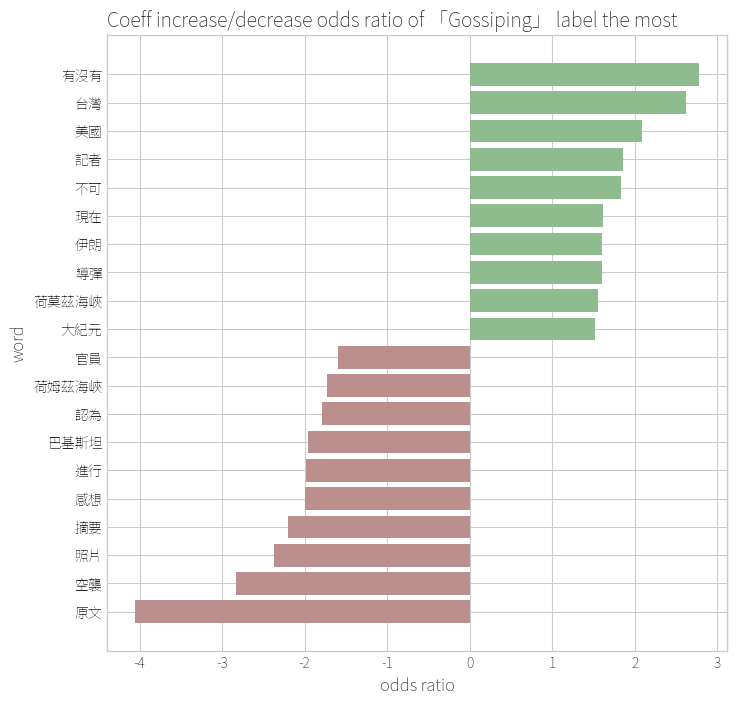

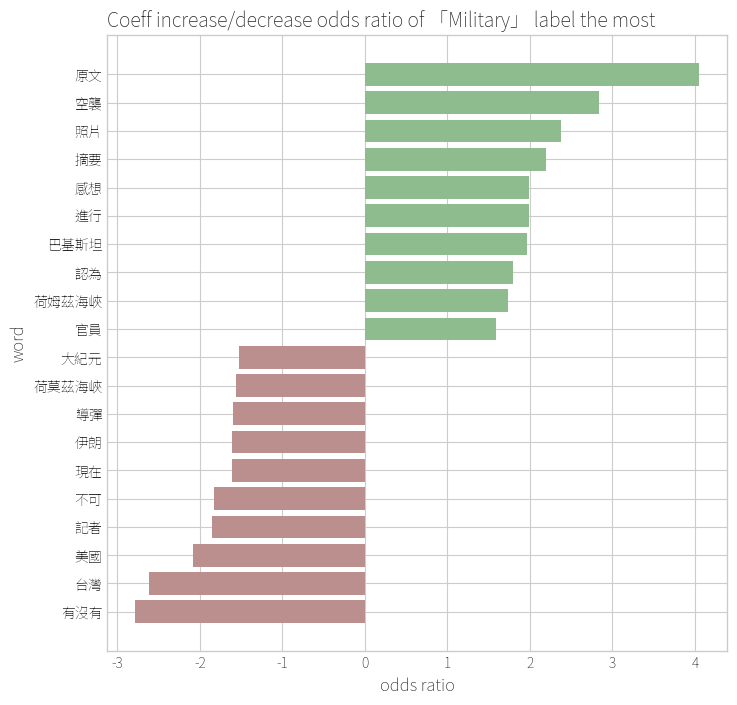

In [68]:
# 呼叫 plot_coef()，畫出 TF-IDF + Logistic Regression 每個類別最重要的正向與負向關鍵詞。

plot_coef(tfidf_logistic, tfidf_vectorizer.get_feature_names_out(), top_n=10)


從係數圖可以看到，模型確實學到兩個版別不同的語言風格。

- `Military` 端通常更容易出現軍事情勢、地緣政治與戰況相關詞，例如空襲、伊拉克、官員、荷姆茲海峽等。
- `Gossiping` 端則更常出現 PTT 問卦或社會討論口吻，例如台灣、有沒有、現在、美國等。
- 這也說明本次分類不只是辨識「伊朗」主題，而是同時辨識兩個版在敘事方式與詞彙選擇上的差異。


## 6. 使用測試集分析最佳模型的錯誤分類結果
原本範例會把分類器套用到另一份資料；但本版 notebook 只使用 `ptt_iran_20260301_0410_full.csv` 一份完整資料，因此這裡改成分析第 3 節切出的 **held-out test set**。

這樣可以避免再使用 `ptt_iran_20260301_0320_new.csv`，同時仍能檢查最佳模型在未參與訓練資料上的實際表現。


In [69]:
# 建立 test_result，把測試集文章資訊與最佳模型預測結果放在同一張表中，方便後續錯誤分析。

test_result = data.loc[X_test.index, ['artDate', 'artCatagory', 'artTitle', 'words']].copy()
test_result['pred'] = y_pred_best_test

test_summary = pd.DataFrame({
    'rows': [len(test_result)],
    'date_min': [test_result['artDate'].min()],
    'date_max': [test_result['artDate'].max()],
    'Gossiping': [(test_result['artCatagory'] == 'Gossiping').sum()],
    'Military': [(test_result['artCatagory'] == 'Military').sum()],
})

test_summary


,rows,date_min,date_max,Gossiping,Military
0,1065,2026-03-01 00:01:58,2026-04-10 22:02:53,785,280


從清理後的資料中，以 7:3 切分出來的測試集。它沒有被最佳模型拿來訓練，因此可以用來觀察模型在未見資料上的分類效果。


In [70]:
# 再次輸出最佳模型在測試集上的分類報告，並預覽前 10 筆測試結果。

print(classification_report(test_result['artCatagory'], test_result['pred']))

test_result[['artDate', 'artCatagory', 'pred', 'artTitle', 'words']].head(10)


              precision    recall  f1-score   support

   Gossiping       0.86      0.98      0.91       785
    Military       0.90      0.55      0.68       280

    accuracy                           0.86      1065
   macro avg       0.88      0.76      0.80      1065
weighted avg       0.87      0.86      0.85      1065



,artDate,artCatagory,pred,artTitle,words
2391,2026-03-12 21:32:14,Gossiping,Gossiping,[爆卦] 伊朗最高領袖命令美國所有中東基地關閉,伊朗 領袖 命令 美國 中東 基地 關閉 伊朗 領袖 就任 首次 發表 演說 伊朗 新任 領袖 一條 重要 石油 運輸 路線 繼續 關閉 伊朗 新任 領袖 穆傑 塔巴 哈米尼 發表 講話 呼籲 伊朗 團結一致 警告 施壓 工具 重要...
1568,2026-03-29 13:09:26,Gossiping,Gossiping,[問卦] 伊朗為何不肯加入西方陣營,伊朗 加入 西方 陣營 國力 夠強 兩邊 想要 好過 通常 加入 西方 陣營 就連 中國 阿富汗 戰爭 脫離 蘇聯 美國 合作 經濟 改革 開放 今天 幾年 關係 緊張 伊朗 明明 石油 要過 日子 不難 西方 作對 看看 台日 還...
3291,2026-03-02 07:38:59,Gossiping,Gossiping,Re: [新聞] 川普：伊朗新任領導層想談判「我同意了」,川普 伊朗 新任 領導層 談判 同意 提到 過往 參與 相關 談判 伊朗 外交 人員 去世 早點 本來 達成 協議 謹慎 了解 阿富汗 伊朗 這種 教義派 穆斯林 狀態 實質 意義 中央 指揮權 哈米尼 這種 共主 名義 共主 真正...
2776,2026-03-06 08:21:43,Gossiping,Gossiping,Re: [爆卦] 美國表示 伊朗戰爭可能持續到9月,美國 伊朗 戰爭 持續 當初 軍武 版講 伊朗 戰爭 打久 台灣 不利 美國 以色列 拖入 派出 地上 部隊 美國人 反對 伊朗 戰爭 正常 軍武 一堆 呆子 還在 嘲諷 美國人 孤立 主義 講個 台灣人 愛聽 戰爭 持續 下去 中...
1280,2026-04-03 23:34:23,Gossiping,Gossiping,[爆卦] 被擊落美軍飛行員之一已獲救撤離伊朗,擊落 美軍 飛行員 獲救 撤離 伊朗 以色列 消息 擊落 攻擊 戰鬥機 兩名 美國 機組 人員 獲救 並從 南部 撤離 美國 官員 證實 一名 飛行員 撤離
3241,2026-03-02 12:38:28,Gossiping,Gossiping,[問卦] 為什麼還不出兵攻佔伊朗？,還不 出兵 攻佔 伊朗 美國 爸爸 美國 爸爸 爸爸 伊朗 身為 孫子 島國 攻佔 伊朗 反共 基地 幾桶 石油 回家
2687,2026-03-07 13:55:36,Gossiping,Gossiping,[問卦] 庫德族：敢死隊願加入推翻伊朗政權,庫德族 敢死隊 加入 推翻 伊朗 政權 庫德族 表態 願意 加入 推翻 伊朗 政權 川普 表態 戰到 伊朗 無條件 投降 無力 反抗 派出 美軍 地面 部隊 後續 發展
2629,2026-03-08 20:17:24,Gossiping,Gossiping,[新聞] 中東大戰第9天！伊朗「4波飛彈」狂轟以,中東 大戰 第天 伊朗 飛彈 狂轟 記者 記者 閔文昱 綜合 中東 大戰 第天 伊朗 飛彈 狂轟 以色列 全境 警報 大作 美國 以色列 伊朗 發動 軍事 進入 第天 中東 局勢 持續 升溫 以色列 晨全境 響起 防空 警報 軍方 ...
241,2026-03-30 23:19:52,Military,Military,[分享] 川普與盧比歐威脅伊朗必須開放荷姆茲海峽,川普 盧比歐 威脅 伊朗 開放 荷姆茲海峽 美利堅 合眾國 理性 伊朗 政權 進行 嚴肅 談判 結束 伊朗 談判 取得 重大 進展 若因 雙方 未能 短期 達成 協議 認為 達成 荷姆茲海峽 未能 立即 恢復 通行 將以 摧毀 徹底...
2826,2026-03-05 17:01:05,Gossiping,Gossiping,[問卦] 北韓：支援伊朗飛彈 一發就把以色列幹掉,北韓 支援 伊朗 飛彈 一發 以色列 幹掉 金正恩 發表 措辭 強硬 聲明 表達 德黑蘭 支持 伊朗 提出 要求 北韓 準備 伊朗 提供 飛彈 用於 打擊 以色列 金正恩 一枚 導彈 足以 消滅 色列 言論 引起 國際 社會 關注 ...


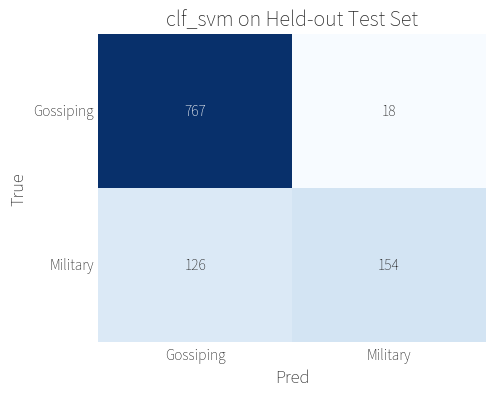

array([[767,  18],
       [126, 154]], dtype=int64)

In [71]:
# 繪製最佳模型在測試集上的混淆矩陣，檢查真實類別與預測類別的對應情況。

plot_confusion(
    test_result['artCatagory'],
    test_result['pred'],
    sorted(test_result['artCatagory'].unique()),
    f'{best_model_name} on Held-out Test Set',
)


In [72]:
# 再次顯示測試集前 10 筆資料，方便與下一步錯誤分類分析銜接。

test_result[['artDate', 'artCatagory', 'pred', 'artTitle', 'words']].head(10)


,artDate,artCatagory,pred,artTitle,words
2391,2026-03-12 21:32:14,Gossiping,Gossiping,[爆卦] 伊朗最高領袖命令美國所有中東基地關閉,伊朗 領袖 命令 美國 中東 基地 關閉 伊朗 領袖 就任 首次 發表 演說 伊朗 新任 領袖 一條 重要 石油 運輸 路線 繼續 關閉 伊朗 新任 領袖 穆傑 塔巴 哈米尼 發表 講話 呼籲 伊朗 團結一致 警告 施壓 工具 重要...
1568,2026-03-29 13:09:26,Gossiping,Gossiping,[問卦] 伊朗為何不肯加入西方陣營,伊朗 加入 西方 陣營 國力 夠強 兩邊 想要 好過 通常 加入 西方 陣營 就連 中國 阿富汗 戰爭 脫離 蘇聯 美國 合作 經濟 改革 開放 今天 幾年 關係 緊張 伊朗 明明 石油 要過 日子 不難 西方 作對 看看 台日 還...
3291,2026-03-02 07:38:59,Gossiping,Gossiping,Re: [新聞] 川普：伊朗新任領導層想談判「我同意了」,川普 伊朗 新任 領導層 談判 同意 提到 過往 參與 相關 談判 伊朗 外交 人員 去世 早點 本來 達成 協議 謹慎 了解 阿富汗 伊朗 這種 教義派 穆斯林 狀態 實質 意義 中央 指揮權 哈米尼 這種 共主 名義 共主 真正...
2776,2026-03-06 08:21:43,Gossiping,Gossiping,Re: [爆卦] 美國表示 伊朗戰爭可能持續到9月,美國 伊朗 戰爭 持續 當初 軍武 版講 伊朗 戰爭 打久 台灣 不利 美國 以色列 拖入 派出 地上 部隊 美國人 反對 伊朗 戰爭 正常 軍武 一堆 呆子 還在 嘲諷 美國人 孤立 主義 講個 台灣人 愛聽 戰爭 持續 下去 中...
1280,2026-04-03 23:34:23,Gossiping,Gossiping,[爆卦] 被擊落美軍飛行員之一已獲救撤離伊朗,擊落 美軍 飛行員 獲救 撤離 伊朗 以色列 消息 擊落 攻擊 戰鬥機 兩名 美國 機組 人員 獲救 並從 南部 撤離 美國 官員 證實 一名 飛行員 撤離
3241,2026-03-02 12:38:28,Gossiping,Gossiping,[問卦] 為什麼還不出兵攻佔伊朗？,還不 出兵 攻佔 伊朗 美國 爸爸 美國 爸爸 爸爸 伊朗 身為 孫子 島國 攻佔 伊朗 反共 基地 幾桶 石油 回家
2687,2026-03-07 13:55:36,Gossiping,Gossiping,[問卦] 庫德族：敢死隊願加入推翻伊朗政權,庫德族 敢死隊 加入 推翻 伊朗 政權 庫德族 表態 願意 加入 推翻 伊朗 政權 川普 表態 戰到 伊朗 無條件 投降 無力 反抗 派出 美軍 地面 部隊 後續 發展
2629,2026-03-08 20:17:24,Gossiping,Gossiping,[新聞] 中東大戰第9天！伊朗「4波飛彈」狂轟以,中東 大戰 第天 伊朗 飛彈 狂轟 記者 記者 閔文昱 綜合 中東 大戰 第天 伊朗 飛彈 狂轟 以色列 全境 警報 大作 美國 以色列 伊朗 發動 軍事 進入 第天 中東 局勢 持續 升溫 以色列 晨全境 響起 防空 警報 軍方 ...
241,2026-03-30 23:19:52,Military,Military,[分享] 川普與盧比歐威脅伊朗必須開放荷姆茲海峽,川普 盧比歐 威脅 伊朗 開放 荷姆茲海峽 美利堅 合眾國 理性 伊朗 政權 進行 嚴肅 談判 結束 伊朗 談判 取得 重大 進展 若因 雙方 未能 短期 達成 協議 認為 達成 荷姆茲海峽 未能 立即 恢復 通行 將以 摧毀 徹底...
2826,2026-03-05 17:01:05,Gossiping,Gossiping,[問卦] 北韓：支援伊朗飛彈 一發就把以色列幹掉,北韓 支援 伊朗 飛彈 一發 以色列 幹掉 金正恩 發表 措辭 強硬 聲明 表達 德黑蘭 支持 伊朗 提出 要求 北韓 準備 伊朗 提供 飛彈 用於 打擊 以色列 金正恩 一枚 導彈 足以 消滅 色列 言論 引起 國際 社會 關注 ...


把錯誤分類的結果篩選出來，觀察哪些文章最容易混淆。


In [73]:
# 篩選出真實分類與預測分類不同的文章，列出模型判斷錯誤的案例。

false_pred = test_result.query('artCatagory != pred').loc[
    :, ['artDate', 'artCatagory', 'pred', 'artTitle', 'words']
]

print(f'錯誤預測筆數: {len(false_pred)} / {len(test_result)}')
false_pred.head(20)


錯誤預測筆數: 144 / 1065


,artDate,artCatagory,pred,artTitle,words
875,2026-03-02 00:38:58,Military,Gossiping,[討論] 伊朗出動殘存的F-4D/E和F-5戰機發起反擊,伊朗 出動 殘存 戰機 發起 反擊 以色列 軍方 影像 伊朗 一架 一架 地面 炸毀 一架 伊朗 準備 起飛 伊朗 剩下 波斯貓 無法 只能 結構 簡單 飛機 進行 反擊 飛機 聯軍 根本 活靶 伊朗 對岸 阿拉伯 輕鬆 火雞 根本...
601,2026-03-09 11:50:27,Military,Gossiping,[新聞] 美以擬派特種部隊 奪伊朗高濃縮鈾,美以 擬派 特種 部隊 伊朗 濃縮鈾 美以 擬派 特種 部隊 伊朗 濃縮鈾 伊朗 公斤 純度 幾週 轉為 武器級 全數 庫存 純度 核彈 阻止 伊朗 取得 核子 武器 美國 總統 川普 公開 宣示 戰爭 目標 伊朗 擁有 四五 公斤...
348,2026-03-23 20:55:46,Military,Gossiping,[新聞] 韓伊外長通話 韓國要求伊朗承諾安全,韓伊 外長 通話 韓國 要求 伊朗 承諾 安全 記者 金泰旭 韓國 外交部 今日 召開 記者會 證實 外交部長 趙顯 伊朗 外交部長 阿巴斯 阿拉 格齊 通話 趙顯 通話 中向 伊朗 表達 韓國 中東 局勢 全球 安全 經濟 不利 ...
39,2026-04-08 14:30:15,Military,Gossiping,Re: [情報] 川普對伊朗談判相關消息數則,川普 伊朗 談判 相關 消息 數則 川普 發文 痛批 伊朗 高層 公告 不實 重點 十點 等於 川普 伊朗 下跪 吉米 先前 補述 似乎 有人還 整理 謠傳 十點 引述 吉米 援用 誤報 打印 字樣 闢謠 截圖 比例 跑掉 圖所示 ...
320,2026-03-25 15:15:01,Military,Gossiping,[討論] 現在其實伊朗就是軍政府治國吧,現在 伊朗 軍政府 治國 談判 事情 軍方 外交部 作用 伊朗 神權 二哈 活著 理論 輪不到 軍方 講話 囚禁 架空 現在 軍方 想談 革命衛隊 不想 革命衛隊 利益 制裁 尋租 盡力 這場 談判 國內 談判 軍政府 同意 二哈要...
507,2026-03-13 14:24:21,Military,Gossiping,[情報] 伊朗持續空襲土耳其,伊朗 持續 空襲 土耳其 伊朗 今天 土耳其 空軍 基地 發射 飛彈 土耳其 之外 北約 盟國 部隊 駐紮 這一 禮拜 伊朗 第三次 空襲 土耳其 先前 土耳其 要來 北約 盟國 額外 一套 愛國 協防 知道 後續 會不會 更多 反應
1164,2026-04-05 14:31:05,Gossiping,Military,[新聞] 專家質疑美國對伊朗Lamerd體育館致命空襲,專家 質疑 美國 伊朗 體育館 致命 空襲 記者 專家 質疑 美國 伊朗 梅爾 體育館 致命 空襲 說法 多名 武器 專家 反駁 美國 說法 美國 聲稱 伊朗 開戰 首日 發生 梅爾 德鎮 一場 致命 空襲 負責 六名 專家 檢視 ...
722,2026-03-05 13:18:05,Military,Gossiping,[情報] 美軍準備對伊朗作戰很可能到今年九月,美軍 準備 伊朗 作戰 今年 九月 節錄 美國 中央 司令部 要求 五角大廈 位於 佛羅里達州 坦帕 總部 增派 更多 軍事 情資 官員 支援 伊朗 至少 為天 持續 這項 消息 政客 取得 一份 通報 文件 川普 首次 伊朗 戰事...
74,2026-04-07 18:23:34,Military,Gossiping,[新聞] 毀滅伊朗倒數計時！航班追蹤器驚見美軍「,毀滅 伊朗 倒數 計時 航班 追蹤器 驚見 美軍 毀滅 伊朗 倒數 計時 航班 追蹤器 驚見 美軍 末日 飛機 起飛 美伊 戰事 膠著 多日 先前 美國 總統 川普 放話 伊朗 期限 達成 和平 協議 該國 恐在 夜間 毀滅 期限 ...
1646,2026-03-27 11:12:30,Gossiping,Military,[新聞] 川普：應伊朗要求 延長停攻10天 談判「進,川普 伊朗 要求 延長 停攻 談判 工商時報 記者 呂佳恩 川普 伊朗 要求 延長 停攻 談判 進展 順利 美國 總統 川普 伊朗 要求 伊朗 能源 設施 暫停 措施 將再 延長 此舉 可望 避免 衝突 進一步 升高 並為 談判 爭...


In [74]:
# 查看真實類別為 Military 但被模型預測錯誤的文章，分析 Military 類文章可能被誤判的原因。

false_pred.loc[false_pred['artCatagory'] == 'Military', :].head(10)


,artDate,artCatagory,pred,artTitle,words
875,2026-03-02 00:38:58,Military,Gossiping,[討論] 伊朗出動殘存的F-4D/E和F-5戰機發起反擊,伊朗 出動 殘存 戰機 發起 反擊 以色列 軍方 影像 伊朗 一架 一架 地面 炸毀 一架 伊朗 準備 起飛 伊朗 剩下 波斯貓 無法 只能 結構 簡單 飛機 進行 反擊 飛機 聯軍 根本 活靶 伊朗 對岸 阿拉伯 輕鬆 火雞 根本...
601,2026-03-09 11:50:27,Military,Gossiping,[新聞] 美以擬派特種部隊 奪伊朗高濃縮鈾,美以 擬派 特種 部隊 伊朗 濃縮鈾 美以 擬派 特種 部隊 伊朗 濃縮鈾 伊朗 公斤 純度 幾週 轉為 武器級 全數 庫存 純度 核彈 阻止 伊朗 取得 核子 武器 美國 總統 川普 公開 宣示 戰爭 目標 伊朗 擁有 四五 公斤...
348,2026-03-23 20:55:46,Military,Gossiping,[新聞] 韓伊外長通話 韓國要求伊朗承諾安全,韓伊 外長 通話 韓國 要求 伊朗 承諾 安全 記者 金泰旭 韓國 外交部 今日 召開 記者會 證實 外交部長 趙顯 伊朗 外交部長 阿巴斯 阿拉 格齊 通話 趙顯 通話 中向 伊朗 表達 韓國 中東 局勢 全球 安全 經濟 不利 ...
39,2026-04-08 14:30:15,Military,Gossiping,Re: [情報] 川普對伊朗談判相關消息數則,川普 伊朗 談判 相關 消息 數則 川普 發文 痛批 伊朗 高層 公告 不實 重點 十點 等於 川普 伊朗 下跪 吉米 先前 補述 似乎 有人還 整理 謠傳 十點 引述 吉米 援用 誤報 打印 字樣 闢謠 截圖 比例 跑掉 圖所示 ...
320,2026-03-25 15:15:01,Military,Gossiping,[討論] 現在其實伊朗就是軍政府治國吧,現在 伊朗 軍政府 治國 談判 事情 軍方 外交部 作用 伊朗 神權 二哈 活著 理論 輪不到 軍方 講話 囚禁 架空 現在 軍方 想談 革命衛隊 不想 革命衛隊 利益 制裁 尋租 盡力 這場 談判 國內 談判 軍政府 同意 二哈要...
507,2026-03-13 14:24:21,Military,Gossiping,[情報] 伊朗持續空襲土耳其,伊朗 持續 空襲 土耳其 伊朗 今天 土耳其 空軍 基地 發射 飛彈 土耳其 之外 北約 盟國 部隊 駐紮 這一 禮拜 伊朗 第三次 空襲 土耳其 先前 土耳其 要來 北約 盟國 額外 一套 愛國 協防 知道 後續 會不會 更多 反應
722,2026-03-05 13:18:05,Military,Gossiping,[情報] 美軍準備對伊朗作戰很可能到今年九月,美軍 準備 伊朗 作戰 今年 九月 節錄 美國 中央 司令部 要求 五角大廈 位於 佛羅里達州 坦帕 總部 增派 更多 軍事 情資 官員 支援 伊朗 至少 為天 持續 這項 消息 政客 取得 一份 通報 文件 川普 首次 伊朗 戰事...
74,2026-04-07 18:23:34,Military,Gossiping,[新聞] 毀滅伊朗倒數計時！航班追蹤器驚見美軍「,毀滅 伊朗 倒數 計時 航班 追蹤器 驚見 美軍 毀滅 伊朗 倒數 計時 航班 追蹤器 驚見 美軍 末日 飛機 起飛 美伊 戰事 膠著 多日 先前 美國 總統 川普 放話 伊朗 期限 達成 和平 協議 該國 恐在 夜間 毀滅 期限 ...
433,2026-03-17 23:27:18,Military,Gossiping,[新聞] 無法昧良心支持川普打伊朗 美國國家反恐,無法 昧良心 支持 川普 伊朗 美國 反恐 原文 聯合報 編譯 高詣 即時 原文 摘要 美國 反恐 中心 主任 肯特 社群 宣布 請職 無法 昧著良心 支持 正在 伊朗 戰爭 肯特 社群 寫給 川普 辭呈 伊朗 美國 並未 構成 迫...
825,2026-03-03 00:41:12,Military,Gossiping,[情報] 卡達擊落兩架伊朗蘇愷24,卡達 擊落 兩架 伊朗 蘇愷 卡達 國防部 卡達 國防部 宣布 偉大 真主 阿拉 之下 擊落 兩架 來犯 伊朗 蘇愷 攔截 七枚 彈道 飛彈 攔截 五架 無人機 阿拉伯 油王們 生氣


In [75]:
# 查看真實類別為 Gossiping 但被模型預測錯誤的文章，分析 Gossiping 類文章可能被誤判的原因。

false_pred.loc[false_pred['artCatagory'] == 'Gossiping', :].head(10)


,artDate,artCatagory,pred,artTitle,words
1164,2026-04-05 14:31:05,Gossiping,Military,[新聞] 專家質疑美國對伊朗Lamerd體育館致命空襲,專家 質疑 美國 伊朗 體育館 致命 空襲 記者 專家 質疑 美國 伊朗 梅爾 體育館 致命 空襲 說法 多名 武器 專家 反駁 美國 說法 美國 聲稱 伊朗 開戰 首日 發生 梅爾 德鎮 一場 致命 空襲 負責 六名 專家 檢視 ...
1646,2026-03-27 11:12:30,Gossiping,Military,[新聞] 川普：應伊朗要求 延長停攻10天 談判「進,川普 伊朗 要求 延長 停攻 談判 工商時報 記者 呂佳恩 川普 伊朗 要求 延長 停攻 談判 進展 順利 美國 總統 川普 伊朗 要求 伊朗 能源 設施 暫停 措施 將再 延長 此舉 可望 避免 衝突 進一步 升高 並為 談判 爭...
1526,2026-03-30 11:07:42,Gossiping,Military,[新聞] 川普：伊朗「已接受大部分」15項停火條,川普 伊朗 接受 大部分 停火 鉅亨網 記者 林羿 川普 伊朗 接受 大部分 停火 條件 美國 總統 川普 德黑蘭 當局 提出 結束 戰爭 目標 要求 伊朗 接受 大部分 條件 外界 無法 確認 雙方 進入 談判 階段 川普 週日 ...
3167,2026-03-02 19:24:02,Gossiping,Military,[新聞] 伊朗發射最先進的飛彈 攻擊以色列總理內,伊朗 發射 先進 飛彈 攻擊 以色列 總理 伊朗 發射 先進 飛彈 攻擊 以色列 總理 唐亞 辦公室 聯合報 編譯 茅毅 即時 伊朗 精銳 伊斯蘭 革命衛隊 聲明 發射 蘭沙 飛彈 攻擊 以色列 總理 唐亞 辦公室 蘭沙 伊朗 先進...
2458,2026-03-11 21:08:48,Gossiping,Military,[新聞] 海格塞斯裁撤了本應調查伊朗學校空襲的辦,海格 塞斯 裁撤 本應 調查 伊朗 學校 空襲 記者 海格 塞斯 裁撤 本應 調查 伊朗 學校 空襲 事件 辦公室 副標題 五角大廈 專注 減緩 平民 傷亡 員工 人數 人驟 降至 不到 國防部長 彼得 海格 塞斯 大幅 裁撤 五角...
2509,2026-03-10 18:49:05,Gossiping,Military,[問卦] 伊朗真的有擊沉油輪嗎???,伊朗 擊沉 油輪 一大堆 不敢過 海峽 伊朗 擊沉 這天 伊朗 擊沉 油輪 波斯灣 變得
1173,2026-04-05 12:58:59,Gossiping,Military,[新聞] 伊朗革命衛隊：擊落MQ-9死神無人機 美軍,伊朗 革命衛隊 擊落 死神 無人機 美軍 劉哲琪 伊朗 革命衛隊 擊落 死神 無人機 美軍 損失 至少 美軍 死神 無人機 示意圖 翻攝 伊朗 伊斯蘭 革命衛隊 稍早 伊斯 法罕 上空 擊落 一架 死神 人機 提供 細節 據報 美國...
2855,2026-03-05 09:43:29,Gossiping,Military,[新聞] 中東局勢再升溫？庫德族傳越境攻打伊朗,中東 局勢 升溫 庫德族 越境 攻打 伊朗 中東 局勢 升溫 庫德族 越境 攻打 伊朗 美國 聯手 以色列 伊朗 進行 重大 軍事 打擊 中東 地區 局勢 急遽 惡化 美國 以色列 數千 伊拉克 庫德族 武裝 人員 週三 越過 邊境...
2685,2026-03-07 14:14:29,Gossiping,Military,[新聞] 美軍4天轟2000目標嚇壞北京 專家：伊朗,美軍 天轟 目標 嚇壞 北京 專家 伊朗 中時 新聞網 許庭瑛 美軍 天轟 目標 嚇壞 北京 專家 伊朗 戰爭 反成 台灣 護盾 美國 伊朗 爆發 戰爭 外界 一度 憂心 美軍 武器 庫存 大量 消耗 削弱 美國 印太地 區的 防衛...
1162,2026-04-05 15:16:40,Gossiping,Military,[新聞] 「伊朗戰爭與我無關，為何是我承擔代價？,伊朗 戰爭 無關 承擔 代價 蘋果 日報 自由時報 參考 版規 下方 核准 名單 直接 官方 允許 風傳媒 記者 記者 名字 名字 外電 至少 法新社 李靖 寫出來 板規 伊朗 戰爭 無關 承擔 代價 巴基斯坦 油價 狂飆 萬人 生...


## 結論

1. `CountVectorizer + LogisticRegression` 可以作為基本示範；改用 `TF-IDF` 後，可以進一步比較不同模型的表現。
2. 在 5-fold CV 的比較下，SVM 與 Random Forest 通常會是表現較好的模型。
3. 係數分析顯示，`Military` 更偏向軍事情勢與戰況詞彙，`Gossiping` 則更偏向 PTT 問卦與社會討論語氣。
4. 若 `Military` 的 recall 偏低，代表模型仍容易把部分軍事板文章判成八卦板，可能原因是兩個版在伊朗戰爭主題上的新聞詞彙與討論語氣有所重疊。


# 三、主題模型

### 使用主題模型找出在伊朗戰爭中，大家重點討論的主題

#### 1. 初始化環境

In [76]:
import re
import time 
from functools import reduce
from collections import Counter
from pprint import pprint
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

import pyLDAvis
import pyLDAvis.gensim_models

In [77]:
BASE_DIR = Path.cwd()
DICT_DIR = BASE_DIR.parent / 'dict'
DATA_DIR = BASE_DIR.parent / 'data'

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

In [78]:
font_path = BASE_DIR / 'font.ttf'
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
else:
    font_name = 'Arial Unicode MS'

plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
print(f'using font: {font_name}')

using font: Noto Sans TC


#### 使用截至04/10的資料

In [79]:
ptt = pd.read_csv("../data/ptt_iran_20260301_0410_full.csv")  # 匯資料
ptt.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,wysptt,Military,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/202604100193.aspx\r\n\r\n新聞內容摘要：\r\n（中央社新德里10日綜合外電報導）美國與伊朗將於11日在巴基斯坦首都伊斯蘭馬...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tony121010"", ""cmtContent"": "": 那麼多石油王，他們會出啦"", ""cmtDate"": ""2026-04-10 20:13:00""}, {""...",2026-04-13 22:25:19,ptt
1,2,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,[情報] 幾則關於伊朗戰爭的民調,2026-04-10 16:20:52,jimmy5680,Military,https://x.com/NateSilver538/status/2039839743404363863\r\n根據Nate Silver的統整各間民調，\r\n可見美國民眾對伊朗戰爭的支持度持續下滑\r\nhttps://pb...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""MarchelKaton"", ""cmtContent"": "": 川普還嗆右派名嘴不是MAGA自己人了"", ""cmtDate"": ""2026-04-10 17:53:...",2026-04-13 22:25:19,ptt
2,3,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,2026-04-10 15:54:15,jimmy5680,Military,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry/status/2042217021010571332\r\nhttps://t.co/e88nkwJ8hQ\r\n\r\n中國從伊朗戰爭中...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""jinkela1"", ""cmtContent"": "": 可寫一整篇回文 但總而言之 台灣情況和伊朗天差地別"", ""cmtDate"": ""2026-04-10 15:...",2026-04-13 22:25:20,ptt


#### 2.1 進行為ptt文章設計的文字清除

In [80]:
custom_words = [
    '防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東',
    '大馬士革', '德黑蘭', '哈梅內伊', '哈米尼', '霍爾木茲海峽',
    '荷姆茲海峽', '荷莫茲海峽','彈道飛彈','革命衛隊'
]

synonyms = {
    '哈梅內伊': '哈米尼',
    '霍爾木茲': '荷姆茲',
    '荷莫茲': '荷姆茲',
    '阿川': '川普',
    '川皇': '川普',
}

manual_stopwords = {
    # --- 原始清單 ---
    '-----', '----', '連結', '嘖嘖', '醒醒', '裝睡', '衛生紙', '乳摸', '高潮',
    '新聞', '內文', '備註', '刪除', '完整', '轉載', '編輯', '張貼', '署名',
    '文章', '標題', '報導', '八卦', '看板', '作者', '時間', '來源', '內容',
    '媒體', '情況', '問題', '如題', '原因', '網址', '發信', '實業', 'cc',
    'ptt', 'gossiping', 'www', 'com', 'https', 'http', 'share', 'url', 'index',
    'html', 'bbs', 'status', '表示', '行動', '國家', '當作', '出現', '晚間',
    '政府', '目前', '請放', '最後', '違者', '未滿', '繁體', '中文字', '水桶',
    '一天', '以天', '單位', '網友', '點擊', '情報', '分享', '問卦', '討論',
    '心得', '爆卦', '認為', '進行', '持續', '指出', '顯示', '要求', '造成', '提供',
    '使用', '希望', '需要', '提出', '決定', '發生', '透過', '告訴', '現在', '相關', 
    '這場', '一名', '這種', '這一', '正在', '包括', '原文', '一直', '一堆', '有沒有', '看到','一道',

    # --- 新增：報導與描述語境詞 (避免干擾軍事核心語意) ---
    '消息', '影片', '影像', '畫面', '回應', '公開', '影響', '證實', '傳出', '報導',
    '直接', '繼續', '擁有', '重要', '並未', '完全', '試圖', '方面', '過去', '可能', 
    '似乎', '甚至', '其實', '覺得', '應該', '只是', '感覺', '發現', '真的', '當時',
    '今天', '昨天', '一些', '以及', '的話', '一個', '一樣', '一般', '一次', '留言',

    # --- 新增：常見副詞與結構詞 (LDA 雜訊) ---
    '比較', '已經', '特別', '非常', '或是', '之後', '結果', '大家', '不可', '一點'
}

jieba.set_dictionary(str(DICT_DIR / 'dict.txt'))
jieba.load_userdict(str(DICT_DIR / 'user_dict.txt'))
for word in custom_words:
    jieba.add_word(word)

stopwords = []
for stopword_file in [DICT_DIR / 'stopwords.txt', DICT_DIR / 'text_stopwords.txt']:
    with open(stopword_file, encoding='utf-8') as f:
        stopwords.extend([line.strip() for line in f if line.strip()])
stopwords = set(stopwords) | manual_stopwords


def clean_ptt_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'※\s*(發信站|文章網址|編輯).*', '', text)
    text = re.sub(r'引述《.*?》之銘言', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    text = re.sub(r'[-/=_~]{2,}', '', text)
    text = re.sub(r'[^\u4e00-\u9fa5\n]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def getToken(text):
    tokens = []
    for word in jieba.lcut(text):
        word = synonyms.get(word, word).strip()
        if len(word) >= 2 and word not in stopwords:
            tokens.append(word)
    return tokens


def prepare_ptt_documents(df, drop_missing_label=True):
    data = df[['artUrl', 'artTitle', 'artContent', 'artCatagory', 'artDate']].copy()
    subset = ['artTitle', 'artContent'] + (['artCatagory'] if drop_missing_label else [])
    data = data.dropna(subset=subset)
    data = data.drop_duplicates(subset='artUrl').copy()
    data['artDate'] = pd.to_datetime(data['artDate'], errors='coerce')
    data['title_clean'] = data['artTitle'].map(clean_ptt_text)
    data['content_clean'] = data['artContent'].map(clean_ptt_text)
    data['content'] = (data['title_clean'] + ' ' + data['content_clean']).str.strip()
    data['words'] = data['content'].apply(getToken)
    data = data[data['words'].str.len() > 0].copy()
    return data


def plot_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues, cbar=False, ax=ax)
    ax.set(
        xlabel='Pred',
        ylabel='True',
        xticklabels=classes,
        yticklabels=classes,
        title=title,
    )
    plt.yticks(rotation=0)
    plt.show()
    return cm

Building prefix dict from C:\Users\justi\OneDrive\文件\中山碩士\社媒\Social_Network_Analysis_Group_3-main\groupwork2\dict\dict.txt ...
Loading model from cache C:\Users\justi\AppData\Local\Temp\jieba.u8028ad36b404e2a685691e04a294fe4e.cache
Loading model cost 0.372 seconds.
Prefix dict has been built successfully.


In [81]:
ptt_clean = prepare_ptt_documents(ptt)

ptt_clean.head(3)

,artUrl,artTitle,artContent,artCatagory,artDate,title_clean,content_clean,content,words
0,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/202604100193.aspx\r\n\r\n新聞內容摘要：\r\n（中央社新德里10日綜合外電報導）美國與伊朗將於11日在巴基斯坦首都伊斯蘭馬...,Military,2026-04-10 20:12:41,保護伊朗人員前來 巴基斯坦空軍闢安全,新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 今日印度報 報導 巴基斯坦為確保安全而...,保護伊朗人員前來 巴基斯坦空軍闢安全 新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 ...,"[保護, 伊朗, 人員, 前來, 巴基斯坦, 空軍, 安全, 出處, 摘要, 中央社, 新德里, 綜合, 外電, 美國, 伊朗, 將於日, 巴基斯坦, 首都, 伊斯蘭, 巴德, 舉行, 萬眾矚目, 談判, 外媒, 披露, 巴基斯坦,..."
1,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,[情報] 幾則關於伊朗戰爭的民調,https://x.com/NateSilver538/status/2039839743404363863\r\n根據Nate Silver的統整各間民調，\r\n可見美國民眾對伊朗戰爭的支持度持續下滑\r\nhttps://pb...,Military,2026-04-10 16:20:52,幾則關於伊朗戰爭的民調,根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世界上的負面力量的比例達 ...,幾則關於伊朗戰爭的民調 根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世...,"[幾則, 伊朗, 戰爭, 民調, 統整, 各間, 民調, 美國, 民眾, 伊朗, 戰爭, 支持度, 下滑, 民調, 追蹤, 美國, 民眾, 以色列, 納坦雅胡, 支持度, 美國, 民眾, 越來越, 厭惡, 以色列, 納坦雅胡, 天空..."
2,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry/status/2042217021010571332\r\nhttps://t.co/e88nkwJ8hQ\r\n\r\n中國從伊朗戰爭中...,Military,2026-04-10 15:54:15,大西洋期刊 中國從伊朗戰爭學到什麼,大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限 即使伴隨著種族滅絕的威 脅 也可能...,大西洋期刊 中國從伊朗戰爭學到什麼 大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限...,"[大西洋, 期刊, 中國, 伊朗, 戰爭, 學到, 大西洋, 期刊, 這篇, 不予置評, 參考, 中國, 伊朗, 戰爭, 中學, 台灣, 實施, 封鎖, 全球, 經濟, 衝擊, 將比, 伊朗, 封鎖, 荷姆茲海峽, 嚴重, 中國, ..."


#### 2.2 只保留'content_clean', 'artUrl', 'artCatagory', 'artDate','words'

In [82]:
ptt_clean = ptt_clean.loc[:,['content_clean', 'artUrl', 'artCatagory', 'artDate','words']]

ptt_clean.head(3)

,content_clean,artUrl,artCatagory,artDate,words
0,新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 今日印度報 報導 巴基斯坦為確保安全而...,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,Military,2026-04-10 20:12:41,"[保護, 伊朗, 人員, 前來, 巴基斯坦, 空軍, 安全, 出處, 摘要, 中央社, 新德里, 綜合, 外電, 美國, 伊朗, 將於日, 巴基斯坦, 首都, 伊斯蘭, 巴德, 舉行, 萬眾矚目, 談判, 外媒, 披露, 巴基斯坦,..."
1,根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世界上的負面力量的比例達 ...,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,Military,2026-04-10 16:20:52,"[幾則, 伊朗, 戰爭, 民調, 統整, 各間, 民調, 美國, 民眾, 伊朗, 戰爭, 支持度, 下滑, 民調, 追蹤, 美國, 民眾, 以色列, 納坦雅胡, 支持度, 美國, 民眾, 越來越, 厭惡, 以色列, 納坦雅胡, 天空..."
2,大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限 即使伴隨著種族滅絕的威 脅 也可能...,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,Military,2026-04-10 15:54:15,"[大西洋, 期刊, 中國, 伊朗, 戰爭, 學到, 大西洋, 期刊, 這篇, 不予置評, 參考, 中國, 伊朗, 戰爭, 中學, 台灣, 實施, 封鎖, 全球, 經濟, 衝擊, 將比, 伊朗, 封鎖, 荷姆茲海峽, 嚴重, 中國, ..."


#### 2.3 文章內容統計

In [83]:
ptt_clean['artCatagory'].unique()

array(['Military', 'Gossiping'], dtype=object)

In [84]:
ptt_clean['artCatagory'].value_counts()

artCatagory
Gossiping    2616
Military      931
Name: count, dtype: int64

#### 軍事板前詞頻前100關鍵字

In [85]:
military_cnt = ptt_clean.loc[ptt_clean['artCatagory'] == 'Military',:]['words'].explode().value_counts().head(100)
military_cnt.index

Index(['伊朗', '美國', '川普', '以色列', '戰爭', '攻擊', '美軍', '飛彈', '官員', '目標', '軍事', '打擊',
       '總統', '無人機', '部隊', '談判', '政權', '空襲', '發動', '中國', '設施', '支持', '中東', '能力',
       '人士', '石油', '發射', '安全', '荷姆茲海峽', '真主黨', '德黑蘭', '地區', '革命衛隊', '衝突', '協議',
       '結束', '威脅', '基地', '停火', '作戰', '伊拉克', '摧毀', '計畫', '黎巴嫩', '伊斯蘭', '能源',
       '達成', '系統', '領袖', '海峽', '哈米尼', '經濟', '武器', '地面', '無法', '聯合', '全球', '國際',
       '防空', '接受', '基礎', '戰略', '烏克蘭', '轟炸', '海灣', '俄羅斯', '人員', '外交', '國防軍',
       '記者', '聲稱', '盟友', '武裝', '船隻', '白宮', '海軍', '彈道飛彈', '歐洲', '政治', '襲擊',
       '彈藥', '國會', '公司', '領導人', '軍方', '主要', '空軍', '警告', '知道', '遭到', '長期',
       '波斯灣', '聲明', '削弱', '組織', '專家', '之間', '封鎖', '大規模', '準備'],
      dtype='object', name='words')

#### 八卦板前詞頻前100關鍵字

In [86]:
gossiping_cnt = ptt_clean.loc[ptt_clean['artCatagory'] == 'Gossiping',:]['words'].explode().value_counts().head(100)
gossiping_cnt.index

Index(['伊朗', '美國', '川普', '以色列', '戰爭', '中國', '美軍', '攻擊', '台灣', '飛彈', '中東', '軍事',
       '總統', '無人機', '記者', '石油', '目標', '談判', '打擊', '基地', '政權', '世界', '哈米尼',
       '設施', '知道', '發動', '領袖', '導彈', '中共', '支持', '部隊', '革命衛隊', '全球', '安全',
       '能源', '官員', '國際', '俄羅斯', '空襲', '海峽', '根本', '武器', '德黑蘭', '能力', '襲擊',
       '美以', '系統', '地區', '無法', '經濟', '威脅', '投降', '結束', '轟炸', '地面', '封鎖', '摧毀',
       '防空', '美元', '烏克蘭', '衝突', '協議', '伊斯蘭', '人士', '核武', '荷莫茲海峽', '油價', '發射',
       '停火', '荷姆茲海峽', '戰略', '海軍', '高層', '警告', '報復', '達成', '綜合', '接受', '至少',
       '政治', '卡達', '準備', '人員', '天然氣', '作戰', '制裁', '空軍', '波斯灣', '宣布', '日本',
       '強調', '原油', '專家', '伊拉克', '阿拉伯', '民眾', '船隻', '關係', '公司', '遭到'],
      dtype='object', name='words')

#### 2.4 自定義主題字典

In [87]:
custom_topic_word = {
    "中東衝突核心": [
        "伊朗", "以色列", "中東", "德黑蘭", "黎巴嫩", "伊拉克", "敘利亞", "加薩", "波斯灣", "哈瑪斯"
    ],
    "軍事行動與武裝": [
        "戰爭", "攻擊", "飛彈", "無人機", "空襲", "彈道飛彈", "打擊", "發射", "軍事", 
        "基地", "摧毀", "武器", "防空系統", "轟炸", "導彈", "地面行動", "國防軍", "彈道", "武裝", "報復"
    ],
    "政治領袖與組織": [
        "川普", "美軍", "哈米尼", "革命衛隊", "真主黨", "總統", "政權", "領袖", "中共", "盟友", "白宮"
    ],
    "地緣政治與大國": [
        "美國", "中國", "台灣", "俄羅斯", "烏克蘭", "全球", "國際", "戰略", "外交", "歐盟", "日本"
    ],
    "能源與經濟衝擊": [
        "石油", "能源", "油價", "經濟", "荷姆茲海峽", "天然氣", "海峽", "封鎖", "美元", "制裁", "原油"
    ],
    "外交與停火談判": [
        "談判", "協議", "停火", "結束", "達成", "要求", "安全", "接受", "支持", "聯合國", "聲明"
    ]
}

#### 統整出關鍵字庫

In [88]:
vocabularies = np.unique(reduce(lambda x, y: x + y, custom_topic_word.values()))

In [89]:
vocabularies

array(['中共', '中國', '中東', '以色列', '伊拉克', '伊朗', '俄羅斯', '停火', '全球', '制裁',
       '加薩', '協議', '原油', '台灣', '哈瑪斯', '哈米尼', '國防軍', '國際', '地面行動', '基地',
       '報復', '外交', '天然氣', '安全', '封鎖', '導彈', '川普', '彈道', '彈道飛彈', '德黑蘭',
       '戰爭', '戰略', '打擊', '接受', '摧毀', '支持', '攻擊', '政權', '敘利亞', '日本', '歐盟',
       '武器', '武裝', '油價', '波斯灣', '海峽', '烏克蘭', '無人機', '發射', '白宮', '盟友',
       '真主黨', '石油', '空襲', '結束', '經濟', '總統', '美元', '美國', '美軍', '聯合國', '聲明',
       '能源', '荷姆茲海峽', '要求', '談判', '軍事', '轟炸', '達成', '防空系統', '革命衛隊', '領袖',
       '飛彈', '黎巴嫩'], dtype='<U5')

#### 產出 DTM_df 表格，橫列為文章、直欄為關鍵字，格點數值則代表該字出現次數。

In [90]:
ptt_corpus = ptt_clean['words'].map(" ".join)
vectorizer = CountVectorizer(vocabulary=vocabularies)
ptt_matrix = vectorizer.fit_transform(ptt_corpus)

ptt_matrix = ptt_matrix.toarray()
feature_names = vectorizer.get_feature_names_out()

DTM_df = pd.DataFrame(columns = feature_names, data = ptt_matrix)
DTM_df

,中共,中國,中東,以色列,伊拉克,伊朗,俄羅斯,停火,全球,制裁,...,要求,談判,軍事,轟炸,達成,防空系統,革命衛隊,領袖,飛彈,黎巴嫩
0,0,0,0,1,0,8,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
1,0,1,0,2,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,12,0,0,0,14,0,2,8,0,...,0,1,2,0,0,0,0,1,0,0
3,0,0,0,4,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,1,2,0,9,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3542,0,0,1,1,0,7,0,0,0,0,...,0,0,5,0,0,0,1,0,2,0
3543,0,0,0,2,0,4,0,0,0,0,...,0,0,3,0,0,0,0,0,0,0
3544,0,0,0,1,0,5,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3545,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 主題統計

In [91]:
df_count = pd.DataFrame({})

# k 是主題名稱，v 是這個主題下的詞彙list
for k, v in custom_topic_word.items():
    idx = np.isin(
        feature_names,
        v
    )
    df_count[f'topic_{k}'] = ptt_matrix[:, idx].sum(axis=1)
    
df_count

,topic_中東衝突核心,topic_軍事行動與武裝,topic_政治領袖與組織,topic_地緣政治與大國,topic_能源與經濟衝擊,topic_外交與停火談判
0,12,1,0,2,0,5
1,5,3,0,7,0,1
2,14,13,17,55,28,5
3,8,2,0,0,0,0
4,17,6,4,4,0,2
...,...,...,...,...,...,...
3542,11,18,2,3,1,1
3543,6,3,2,2,0,0
3544,6,1,0,4,0,0
3545,4,0,0,0,0,0


#### 計算文章的主題權重 ($\theta$)

In [92]:
thetas = df_count.div(
    df_count.sum(axis=1),
    axis=0
)
thetas.head()

,topic_中東衝突核心,topic_軍事行動與武裝,topic_政治領袖與組織,topic_地緣政治與大國,topic_能源與經濟衝擊,topic_外交與停火談判
0,0.600000,0.050000,0.000000,0.100000,0.000000,0.250000
1,0.312500,0.187500,0.000000,0.437500,0.000000,0.062500
2,0.106061,0.098485,0.128788,0.416667,0.212121,0.037879
3,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000
4,0.515152,0.181818,0.121212,0.121212,0.000000,0.060606


### 3.LDA模型

In [93]:
docs = ptt_clean['words'].to_list()
docs[0]

['保護',
 '伊朗',
 '人員',
 '前來',
 '巴基斯坦',
 '空軍',
 '安全',
 '出處',
 '摘要',
 '中央社',
 '新德里',
 '綜合',
 '外電',
 '美國',
 '伊朗',
 '將於日',
 '巴基斯坦',
 '首都',
 '伊斯蘭',
 '巴德',
 '舉行',
 '萬眾矚目',
 '談判',
 '外媒',
 '披露',
 '巴基斯坦',
 '空軍',
 '出動',
 '大批',
 '軍機',
 '波斯灣',
 '空域',
 '保護',
 '伊朗',
 '代表',
 '前來',
 '赴會',
 '今日',
 '印度',
 '巴基斯坦',
 '確保',
 '安全',
 '開闢',
 '空中',
 '安全',
 '走廊',
 '專家',
 '稱為',
 '鋼鐵',
 '護航',
 '除將',
 '伊斯蘭',
 '巴德',
 '空域',
 '防護',
 '得密',
 '透風',
 '巴基斯坦',
 '加強',
 '南部',
 '西部',
 '空防',
 '伊朗',
 '空軍',
 '幾已',
 '美國',
 '以色列',
 '摧毀',
 '殆盡',
 '巴基斯坦',
 '部署',
 '大量',
 '軍機',
 '伊朗',
 '上空',
 '波斯灣',
 '撐起',
 '防護',
 '保護',
 '伊朗',
 '代表團',
 '飛航',
 '追蹤',
 '數據',
 '巴基斯坦',
 '戰機',
 '伊朗',
 '港市',
 '阿巴斯',
 '附近',
 '負責',
 '護送',
 '載有',
 '伊朗',
 '代表團',
 '飛機',
 '前往',
 '伊斯蘭',
 '巴德',
 '這段',
 '小時',
 '航程',
 '巴基斯坦',
 '空軍',
 '出動',
 '伊留申',
 '空中',
 '加油機',
 '延長',
 '戰機',
 '滯空',
 '派出',
 '空中',
 '預警機',
 '監控',
 '巴基斯坦',
 '波斯灣',
 '空域',
 '巴基斯坦',
 '出動',
 '這麼多',
 '架次',
 '各型',
 '飛機',
 '燃料費',
 '保養費',
 '消耗',
 '想必',
 '驚人',
 '巴國',
 '大手筆',
 '想攬',
 '和平',
 '停戰',
 '談判',
 '主場',
 '想爭',

#### 特徵篩選

In [94]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.8)
print(dictionary)

Dictionary<8352 unique tokens: ['上空', '中央社', '主場', '人員', '今日']...>


#### Word-to-ID 映射

In [95]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

上空: 0
中央社: 1
主場: 2
人員: 3
今日: 4
代表: 5
代表團: 6
以色列: 7
伊斯蘭: 8
保護: 9
停戰: 10
出動: 11


In [96]:
pprint(" ".join(ptt_clean['words'].iloc[600]))

('專訪 伊朗 面臨 一場 革命 華爾街日報 專訪 伊朗 處於 一場 革命 邊緣 歷史 學者 阿里 安薩里 伊朗 當前 政權 面臨 前所未有 危機 長達 '
 '傳統 不斷 建立 法治 體系 奮鬥 專家 伊朗 不可能 政權 更迭 不可能 一月 大規模 抗議 政權 掌握 武力 願意 對領 導人 暴徒 空襲 無法 '
 '空中 打擊 推翻 政權 相信 政治學 阿里 安薩里 看法 堅信 漢娜 阿倫 革命 不可能 後則 避免 安薩里 教授 蘇格蘭 安德魯 大學 歷史學家 負責 '
 '該校 伊朗 研究所 出版 伊朗 一書 了解 現代史 最佳 入門 讀物 擔心 社會 科學家 國際 關係 專家 依賴 分析 模板 看不到 伊朗 內部 事情 '
 '絕大 多數 掙扎 政治體制 備受 憎恨 經濟 體制 無法 滿足 需求 一段 談中 薪水 無法 維持 生活 需求 環境 危機 地下水 抽乾 面臨 國際 '
 '危機 這說 還算 委婉 想到 一場 危機 伊斯蘭 共和國 面臨 安薩里 強大 穩定 不可能 強大 穩定 每隔 幾年 反抗 規模 之大 政權 視為 生死 '
 '存亡 挑戰 安薩里 估計 支持 政權 人口 相信 戰爭 擊敗 美國 停頓 一下 做到 這位 教授 強調 審慎 無法 確定 政權 倒台 認同 一月 抗議 '
 '運動 徹底 鎮壓 說法 美國 以色列 創造 契機 政權 大規模 屠殺 實際 適得其反 宣稱 死亡 鎮壓 成功 但當 隨機 方式 殺害 同胞 病床 開槍 '
 '激起 難以 壓制 憤怒 空襲 學生 重新 抗議 將此 中國 天安門 廣場 屠殺 相比 恰當 有多種 北京 能夠 民眾 好處 政治 壓制 經濟 成功 收買 '
 '正要 成為 大國 伊朗 政權 唯一 伊朗 天堂 開心 聽到 伊朗 殘酷 鎮壓 抗議 抗議 運動 上街 值得 射殺 突然 一月 這股 以往 反抗 浪潮 '
 '視角 拉遠 抗議 手段 加速 一波接 一波 反覆 抗議 傾向 努力 爭取 自由 憲法 革命 遺產 革命 伊朗 贏得 英美 傳統 自由 憲法 建立 法治 '
 '理想 尚未 實踐 安薩里 著作 伊斯蘭 革命 奪走 聚光燈 革命 政治 思想 主義 深遠 傳統 一種 活生生 伊朗 新建 工程 真正 現代化 機構 阿亞 '
 '圖拉們 沙阿手 繼承 下來 教科書 伊斯蘭 革命 始於 伊特 拉拉 特報 發表

In [97]:
dictionary.doc2bow(ptt_clean['words'].iloc[600])[:10]

[(7, 1),
 (8, 8),
 (23, 2),
 (24, 2),
 (43, 1),
 (47, 16),
 (51, 1),
 (52, 2),
 (55, 1),
 (73, 1)]

#### 把所有文件轉換為Bag-of-Words

In [98]:
corpus = [dictionary.doc2bow(doc) for doc in docs]

#### 尋找最佳主題數

In [99]:
t0 = time.time()

topic_num_list = np.arange(2, 10)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # perplexity
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=5 # 訓練次數
        )
    
    loss = model.log_perplexity(corpus)
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)
    
    # model_set[f'k_{topic_num}'] = model
    
    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)
    
print(f"花費時間: {time.time() - t0} sec")

花費時間: 265.5372176170349 sec


In [100]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,2350.120787,-0.005122
1,3,2244.105597,0.007852
2,4,2259.231106,0.018383
3,5,2222.488965,0.021815
4,6,2207.302981,0.021816
5,7,2211.691337,0.018284
6,8,2239.496802,-0.014895
7,9,2199.312463,-0.001492


<Axes: xlabel='topic_num'>

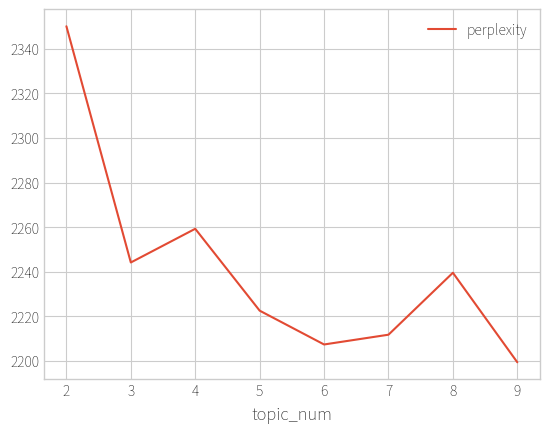

In [101]:
result.plot.line(x='topic_num', y='perplexity')

<Axes: xlabel='topic_num'>

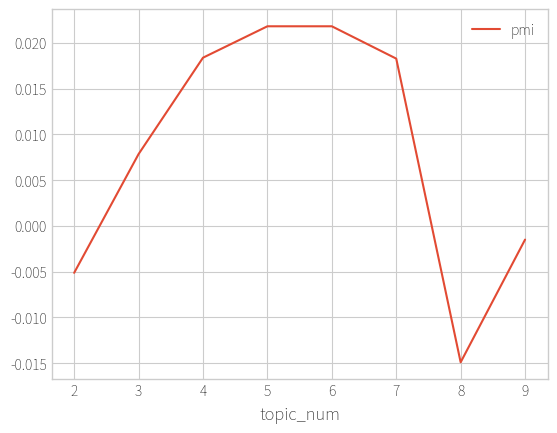

In [102]:
result.plot.line(x='topic_num', y='pmi')

In [103]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 6,
    id2word=dictionary,
    random_state = 1500,
    passes = 20
    )

#### 視覺化

In [104]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.030201 -0.025764       1        1  26.788641
3     -0.109369  0.172102       2        1  22.479596
2      0.032888 -0.119407       3        1  19.675648
0     -0.038611 -0.186632       4        1  13.777203
1     -0.173500  0.057755       5        1   9.505447
5      0.258391  0.101947       6        1   7.773464, topic_info=    Term         Freq         Total Category  logprob  loglift
189   川普  6169.000000   6169.000000  Default  30.0000  30.0000
74    中國  2330.000000   2330.000000  Default  29.0000  29.0000
279   石油  1131.000000   1131.000000  Default  28.0000  28.0000
295   美軍  2736.000000   2736.000000  Default  27.0000  27.0000
7    以色列  4290.000000   4290.000000  Default  26.0000  26.0000
..   ...          ...           ...      ...      ...      ...
291   經濟   169.336731    651.181808   Topic6  -5.1598   1.2076
434   攻擊   249.845388   2727.549040   Topic6  -4.7708   0.1641
47    美國   335.337347  10792.593617   Topic6  -4.4765  -0.9170
74    中國   231.928195   2330.888807   Topic6  -4.8452   0.2469
23    安全   169.303160    937.867297   Topic6  -5.1600   0.8425

[479 rows x 6 columns], token_table=      Topic      Freq Term
term                      
486       1  0.020740   一下
486       2  0.801944   一下
486       3  0.017283   一下
486       5  0.134810   一下
486       6  0.024197   一下
...     ...       ...  ...
7759      5  0.975021   魷魚
8055      5  0.993348   鵝肝
853       1  0.018333  黎巴嫩
853       3  0.979485  黎巴嫩
854       3  0.959234   齊射

[1100 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 1, 2, 6])

#### Topic 1: 外交與美方動態 Topic 2: 兩岸觀點 Topic 3: 伊以對抗 Topic 4: 武裝與裝備 Topic 5: 東亞相關 Topic 6: 能源經濟

In [105]:
pyLDAvis.save_html(p, "lda_zh.html")

### 4. Guidedlda

In [106]:
import guidedlda

In [107]:
word2id = dictionary.token2id

In [108]:
seed_topic_list = [
    ["以色列", "德黑蘭", "黎巴嫩", "伊斯蘭", "加薩"],
    ["戰爭", "攻擊", "飛彈", "無人機", "空襲", "攔截"],
    ["川普", "拜登", "談判", "協議", "停火", "外交"],
    ["美國", "中國", "台灣", "俄羅斯", "烏克蘭", "中共"],
    ["石油", "能源", "油價", "荷姆茲海峽", "封鎖", "原油"],
    ["報導", "消息", "記者", "影片", "大紀元", "中央社"]
]

In [109]:
print('伊朗' in word2id)

print(list(word2id.keys())[:50])

False
['上空', '中央社', '主場', '人員', '今日', '代表', '代表團', '以色列', '伊斯蘭', '保護', '停戰', '出動', '出處', '前往', '加強', '加油機', '南部', '印度', '和平', '外媒', '外電', '大批', '大量', '安全', '專家', '小時', '巴基斯坦', '巴德', '延長', '想必', '戰機', '披露', '摘要', '摧毀', '數據', '架次', '殆盡', '波斯灣', '派出', '消耗', '監控', '確保', '稱為', '空中', '空域', '空軍', '綜合', '美國', '舉行', '航程']


#### 建立種子詞字典

In [110]:
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id
        else:
            # 沒找到就跳過，並印出提醒
            print(f"提示：詞彙 '{word}' 已被過濾，不加入種子引導。")

# 檢查一下最後成功的種子數量
print(f"成功對應的種子詞數量: {len(seed_topics)}")

提示：詞彙 '報導' 已被過濾，不加入種子引導。
提示：詞彙 '消息' 已被過濾，不加入種子引導。
提示：詞彙 '影片' 已被過濾，不加入種子引導。
成功對應的種子詞數量: 32


In [111]:
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

#### 訓練引導式模型

In [112]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

INFO:guidedlda:n_documents: 3547
INFO:guidedlda:vocab_size: 8352
INFO:guidedlda:n_words: 379315
INFO:guidedlda:n_topics: 6
INFO:guidedlda:n_iter: 100
INFO:guidedlda:<0> log likelihood: -3797863
INFO:guidedlda:<20> log likelihood: -3093098
INFO:guidedlda:<40> log likelihood: -3067267
INFO:guidedlda:<60> log likelihood: -3057532
INFO:guidedlda:<80> log likelihood: -3052282
INFO:guidedlda:<99> log likelihood: -3050704


#### 結果

In [113]:
# 整理／顯示主題模型結果
n_top_words = 10
topic_word = model.topic_word_
# 取得corpus全部的詞彙表
vocab = tuple(dictionary.token2id.keys())

for i, topic_dist in enumerate(topic_word):
    # 依照詞語機率從小到大排序，找出每個主題的前十個關鍵詞
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_ # 文件-主題 分佈
term_freq = tuple(dictionary.cfs.values()) # 每個詞在整個語料中出現的總次數
doc_len = [sum(v for k, v in doc) for doc in corpus] # 每篇文章的長度

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 以色列 攻擊 美國 革命衛隊 發動 打擊 設施 空襲 部隊 真主黨
Topic 1: 美軍 飛彈 無人機 美國 系統 攻擊 基地 目標 打擊 防空
Topic 2: 川普 美國 戰爭 總統 談判 官員 軍事 協議 以色列 結束
Topic 3: 美國 中國 川普 台灣 戰爭 以色列 知道 世界 根本 中東
Topic 4: 石油 中國 美國 能源 全球 海峽 荷姆茲海峽 經濟 船隻 美元
Topic 5: 哈米尼 中共 記者 政權 中國 民眾 領袖 軍事 國際 總統


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.009467  0.064580       1        1  25.151906
3     -0.047413  0.053250       2        1  21.296144
1      0.193377  0.069100       3        1  16.421895
0      0.123068  0.099508       4        1  13.345536
4      0.032901 -0.327888       5        1  12.244197
5     -0.311400  0.041450       6        1  11.540323, topic_info=    Term         Freq        Total Category  logprob  loglift
189   川普  6142.000000  6142.000000  Default  30.0000  30.0000
7    以色列  4389.000000  4389.000000  Default  29.0000  29.0000
295   美軍  2778.000000  2778.000000  Default  28.0000  28.0000
263  無人機  1616.000000  1616.000000  Default  27.0000  27.0000
386   飛彈  2047.000000  2047.000000  Default  26.0000  26.0000
..   ...          ...          ...      ...      ...      ...
23    安全   151.783423   936.836989   Topic6  -5.6643   0.3393
466   關係   124.823667   381.518413   Topic6  -5.8599   1.0421
8    伊斯蘭   138.802800   683.096936   Topic6  -5.7537   0.5657
99    英國   114.838573   281.644407   Topic6  -5.9433   1.2622
24    專家   116.835592   414.517907   Topic6  -5.9260   0.8930

[456 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
486       2  0.898317    一下
486       4  0.033271    一下
486       5  0.069869    一下
2410      4  0.999597  一廂情願
488       3  1.000869    一架
...     ...       ...   ...
6142      3  1.000363    魚雷
8055      2  1.001183    鵝肝
853       1  0.019936   黎巴嫩
853       2  0.008860   黎巴嫩
853       4  0.970211   黎巴嫩

[784 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 2, 1, 5, 6])

#### Topic 1: 美國動態 Topic 2: 地緣政治 Topic 3: 軍事行動 Topic 4: 伊以對抗 Topic 5: 能源經濟 Topic 6: 政權穩定

In [114]:
pyLDAvis.save_html(p, "lda_zh_guided.html")

#### 文本主題機率

In [115]:
doc_topic_dist = model.doc_topic_

# 檢查一下形狀，預期應該是 (3547, 6)
print(f"分佈矩陣形狀: {doc_topic_dist.shape}")

# 如果你想看第一篇文章在 6 個主題的分機率：
print(f"第一篇文章的主題分佈: \n{doc_topic_dist[0]}")

分佈矩陣形狀: (3547, 6)
第一篇文章的主題分佈: 
[0.19442902 0.45354433 0.23144549 0.07412549 0.03710901 0.00934666]


In [116]:
doc_topic[100]

array([1.02113733e-01, 3.00246202e-05, 8.55731700e-01, 3.00246202e-05,
       4.20644929e-02, 3.00246202e-05])

In [117]:
m_theta = doc_topic_dist 

ptt_clean['topic_label'] = m_theta.argmax(axis=1) + 1

print(ptt_clean['topic_label'].value_counts())

topic_label
4    1630
3     716
2     453
1     308
5     254
6     186
Name: count, dtype: int64


In [118]:
ptt_clean.head()

,content_clean,artUrl,artCatagory,artDate,words,topic_label
0,新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 今日印度報 報導 巴基斯坦為確保安全而...,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,Military,2026-04-10 20:12:41,"[保護, 伊朗, 人員, 前來, 巴基斯坦, 空軍, 安全, 出處, 摘要, 中央社, 新德里, 綜合, 外電, 美國, 伊朗, 將於日, 巴基斯坦, 首都, 伊斯蘭, 巴德, 舉行, 萬眾矚目, 談判, 外媒, 披露, 巴基斯坦,...",2
1,根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世界上的負面力量的比例達 ...,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,Military,2026-04-10 16:20:52,"[幾則, 伊朗, 戰爭, 民調, 統整, 各間, 民調, 美國, 民眾, 伊朗, 戰爭, 支持度, 下滑, 民調, 追蹤, 美國, 民眾, 以色列, 納坦雅胡, 支持度, 美國, 民眾, 越來越, 厭惡, 以色列, 納坦雅胡, 天空...",6
2,大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限 即使伴隨著種族滅絕的威 脅 也可能...,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,Military,2026-04-10 15:54:15,"[大西洋, 期刊, 中國, 伊朗, 戰爭, 學到, 大西洋, 期刊, 這篇, 不予置評, 參考, 中國, 伊朗, 戰爭, 中學, 台灣, 實施, 封鎖, 全球, 經濟, 衝擊, 將比, 伊朗, 封鎖, 荷姆茲海峽, 嚴重, 中國, ...",5
3,以色列媒體報導 以色列軍方告訴國會議員說伊朗的新政府比戰前的更極端 以色列軍方另稱作戰對伊朗造成嚴重打擊 但是伊朗已經開始著手恢復飛彈生產等能力 別把我的肖像掛在你們的辦公室裡 掛上你們孩子的照片 在做每一個決定之前 先看看他們的眼睛,https://www.ptt.cc/bbs/Military/M.1775806937.A.68F.html,Military,2026-04-10 15:42:14,"[以色列, 軍方, 伊朗, 以色列, 以色列, 軍方, 國會, 議員, 伊朗, 戰前, 以色列, 軍方, 另稱, 作戰, 伊朗, 嚴重, 打擊, 伊朗, 著手, 恢復, 飛彈, 生產, 能力, 肖像, 掛在, 辦公室, 掛上, 孩子...",3
4,曾揚言發展核武 伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難 伊朗媒體報導 前伊朗外交部長哈拉濟 月日在美國與以色列的空襲 中受傷 今天傷重不治 哈拉濟曾表示德黑蘭可能會尋求發展核武 法新社報導 歲的哈拉濟生前在隸屬於伊朗外交部的外交...,https://www.ptt.cc/bbs/Military/M.1775801379.A.454.html,Military,2026-04-10 14:09:37,"[曾嗆, 發展, 核武, 伊朗, 外長, 傷重, 不治, 揚言, 發展, 核武, 伊朗, 外長, 拉齊, 遇襲, 住所, 攻擊, 罹難, 伊朗, 伊朗, 外交部長, 哈拉, 美國, 以色列, 空襲, 受傷, 傷重, 不治, 哈拉, ...",1


### 5. 每日主題趨勢

In [119]:
ptt_clean.groupby(ptt_clean['artDate'].dt.date)['topic_label'].value_counts(normalize=True)

artDate     topic_label
2026-03-01  4              0.571429
            1              0.142857
            2              0.100000
            6              0.089286
            3              0.078571
                             ...   
2026-04-10  5              0.200000
            6              0.200000
            1              0.100000
            4              0.100000
            2              0.050000
Name: proportion, Length: 240, dtype: float64

In [120]:
date_topic = ptt_clean.groupby(ptt_clean['artDate'].dt.date)['topic_label'].value_counts(normalize=True).unstack()
date_topic.head()

topic_label,1,2,3,4,5,6
artDate,,,,,,
2026-03-01,0.142857,0.100000,0.078571,0.571429,0.017857,0.089286
2026-03-02,0.102767,0.130435,0.098814,0.588933,0.035573,0.043478
2026-03-03,0.059459,0.102703,0.189189,0.486486,0.064865,0.097297
2026-03-04,0.128378,0.182432,0.128378,0.445946,0.040541,0.074324
2026-03-05,0.120690,0.206897,0.163793,0.413793,0.025862,0.068966


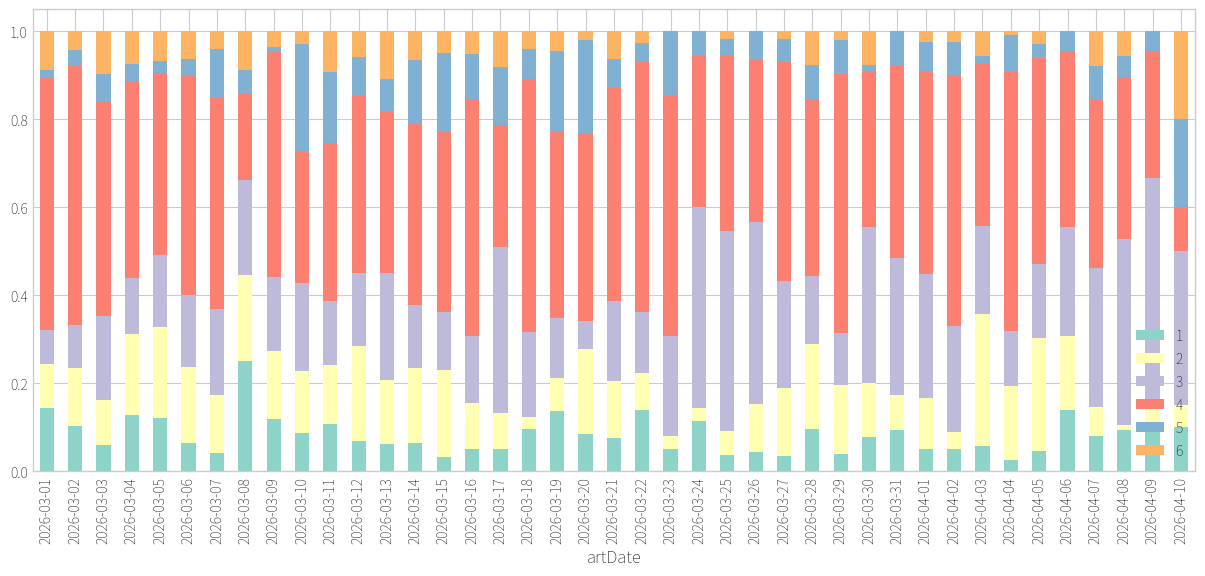

In [121]:
fig, ax = plt.subplots(figsize=(15, 6))
date_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)
ax.legend(loc='lower right')
plt.show()

### 本專案透過 Guided LDA 發現，PTT 社群的輿論呈現 『從戰術到戰略，再到民生經濟』 的轉化規律。衝突初期以軍事（紫色）與核心衝突（紅色）驅動流量，但隨後的關注點會迅速轉向地緣政治（黃色）。最終，影響討論有明顯增長的議題則是能源與經濟（藍色），顯示出台灣使用者對於國際衝突的主題變化。